In [1]:
# # ============================================
# # Run this cell when error about prophet
# # ============================================

# # 1) Clean out any mixed installs
# !pip uninstall -y prophet fbprophet pystan httpstan cmdstanpy numpy

# # 2) Install a compatible stack
# !pip install --no-cache-dir numpy==1.26.4 prophet==1.1.5 cmdstanpy==1.2.4 ujson


In [2]:
# ============================================
# Run this cell when error about prophet
# ============================================

# import cmdstanpy
# cmdstanpy.install_cmdstan()   # one-time; downloads/compiles CmdStan

# import prophet, cmdstanpy
# print("prophet version:", getattr(prophet, "__version__", "unknown"))
# print("cmdstanpy version:", cmdstanpy.__version__)

# from prophet import Prophet
# m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
# print("Prophet constructed OK.")

# # quick smoke test
# import pandas as pd
# df = pd.DataFrame({"ds": pd.date_range("2019-01-31", periods=36, freq="M"),
#                    "y": 100 + pd.Series(range(36))*0.5})
# m.fit(df)
# future = m.make_future_dataframe(periods=6, freq="M")
# fcst = m.predict(future)
# fcst[["ds","yhat"]].tail()


CmdStan install directory: /root/.cmdstan
Installing CmdStan version: 2.37.0
Download successful, file: /tmp/tmpqm76q3av
Extracting distribution


DEBUG:cmdstanpy:cmd: make build -j1
cwd: None


Unpacked download as cmdstan-2.37.0
Building version cmdstan-2.37.0, may take several minutes, depending on your system.


DEBUG:cmdstanpy:cmd: make examples/bernoulli/bernoulli
cwd: None


Installed cmdstan-2.37.0
Test model compilation


/tmp/ipython-input-2865744261.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df = pd.DataFrame({"ds": pd.date_range("2019-01-31", periods=36, freq="M"),
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvu1aeee8/wyf6zjbi.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpvu1aeee8/ky669fd4.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=31745', 'data', 'file=/tmp/tmpvu1aeee8/wyf6zjbi.json', 'init=/tmp/tmpvu1aeee8/ky669fd4.json', 'output', 'file=/tmp/tmpvu1aeee8/prophet_modelto8nuvi4/prophet_model-20251114052211.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
05:22:11 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing


prophet version: 1.1.5
cmdstanpy version: 1.2.4
Prophet constructed OK.


05:22:34 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds,yhat
37,2022-02-28,118.344175
38,2022-03-31,119.014182
39,2022-04-30,119.772432
40,2022-05-31,120.353662
41,2022-06-30,120.807606


In [3]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)  # brand-new empty folder

Mounted at /content/drive


In [4]:
# ============================================
# Silence Prophet, CmdStanPy, and SciPy logs
# ============================================

import logging
import warnings
import os

# 1️⃣ Suppress common warnings (FutureWarning, UserWarning, etc.)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# 2️⃣ Suppress Prophet and CmdStanPy logs
logging.getLogger("cmdstanpy").disabled = True
logging.getLogger("prophet").disabled = True
logging.getLogger("matplotlib").setLevel(logging.ERROR)

# 3️⃣ Reduce verbosity for scipy / numpy internal solvers
os.environ["PYTHONWARNINGS"] = "ignore"
os.environ["NUMEXPR_MAX_THREADS"] = "8"
os.environ["NUMEXPR_NUM_THREADS"] = "8"

# 4️⃣ Hide CmdStan output completely
os.environ["CMDSTANPY_VERBOSE"] = "False"
os.environ["STAN_NUM_THREADS"] = "1"
os.environ["PROPHET_LOG_LEVEL"] = "ERROR"

# 5️⃣ Optional: quiet tqdm progress bars
try:
    from tqdm.auto import tqdm
    tqdm.__init__ = lambda *a, **k: None
except:
    pass

print("✅ All noisy logs and warnings suppressed — only key results will show.")


✅ All noisy logs and warnings suppressed — only key results will show.


In [5]:
# Paths
crime_path = "/content/drive/MyDrive/Colab Notebooks/merged_crime_racecode_crimeCode.csv"
pop_path   = "/content/drive/MyDrive/Colab Notebooks/Merge_populationone_census.csv"

# 1) Load CSVs
import pandas as pd
crime = pd.read_csv(crime_path, low_memory=False)
pop   = pd.read_csv(pop_path,  low_memory=False)


# 3) Quick structure + preview
print("=== Crime data ===")
print(crime.shape)
display(crime.head())

print("=== Population census data ===")
print(pop.shape)
display(pop.head())


=== Crime data ===
(2398392, 35)


,DR_NO,DATE RPTD,DATE OCC,TIME OCC,AREA,AREA NAME,RPT DIST NO,PART 1-2,CRM CD,CRM CD DESC,...,CROSS STREET,LAT,LON,GEOID,CT,ZCTA,YEAR,ZCTA_YEAR_KEY,CRM CD Main Type,Vict Race Desc
0,130814829,2013-09-30,2013-09-27,18,8,West LA,838,1,310,BURGLARY,...,NaN,34.0620,-118.4480,6.037265e+09,265305.0,90024.0,2013,90024_2013,BURGLARY,White
1,130209056,2013-03-28,2013-03-27,19,2,Rampart,216,1,510,VEHICLE - STOLEN,...,BELLEVUE AV,34.0734,-118.2678,6.037196e+09,195710.0,90026.0,2013,90026_2013,Stolen Vehicle,Unknown
2,140107110,2014-02-15,2013-12-31,9,1,Central,192,1,341,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",...,SANTA MONICA FY,34.0363,-118.2672,6.037224e+09,224010.0,90015.0,2013,90015_2013,OTHER THEFT,Black
3,130517919,2013-11-14,2013-10-29,17,5,Harbor,583,1,310,BURGLARY,...,NaN,33.7203,-118.3026,6.037298e+09,297500.0,90731.0,2013,90731_2013,BURGLARY,White
4,131916227,2013-07-23,2013-05-10,0,19,Mission,1912,2,845,SEX OFFENDER REGISTRANT OUT OF COMPLIANCE,...,NaN,34.3178,-118.4739,6.037107e+09,106510.0,91342.0,2013,91342_2013,SEX CRIMES,Unknown


=== Population census data ===
(3345, 47)


,OBJECTID,CT,FIP,CITY,SPA,SPA_NAME,HD,HD_NAME,POP_AGE_0_4,POP_AGE_5_9,...,POV_TOTAL,AREA_SQMIL,POP_DENSITY,POV_RATE,SHAPE__AREA,SHAPE__LENGTH,GEOID,ZCTA,YEAR,ZCTA_YEAR_KEY
0,1,101110,44000,Los Angeles city,2,San Fernando,19,East Valley,205,235,...,706,0.441031,10808.761643,14.810153,1.229524e+07,15084.302753,6037101110,91042.0,2013,91042_2013
1,7,102103,44000,Los Angeles city,2,San Fernando,19,East Valley,80,82,...,17,0.458065,3888.097400,0.954520,1.277011e+07,16350.730487,6037102103,91352.0,2013,91352_2013
2,8,102104,44000,Los Angeles city,2,San Fernando,19,East Valley,176,179,...,234,0.641356,5765.905705,6.327745,1.787999e+07,27570.450102,6037102104,91504.0,2013,91504_2013
3,11,103101,44000,Los Angeles city,2,San Fernando,19,East Valley,130,119,...,193,0.783648,3462.013209,7.113896,2.184685e+07,25422.120896,6037103101,91040.0,2013,91040_2013
4,17,104103,44000,Los Angeles city,2,San Fernando,19,East Valley,342,291,...,274,0.367216,11451.012018,6.516052,1.023741e+07,13287.806933,6037104103,91342.0,2013,91342_2013


In [6]:
# ============================================
# Uncomment if need the merge file
# ============================================


# crime_population = crime.merge(
#     pop,
#     on="ZCTA_YEAR_KEY",
#     how="left",
#     validate="many_to_one",
#     suffixes=("", "_pop")
# )

# print(f"crime: {crime.shape} | pop: {pop.shape} | merged: {crime_population.shape}")

In [7]:
# ============================================
# Uncomment if need the merge file
# ============================================

# crime_population = crime.merge(
#     pop,
#     on="ZCTA_YEAR_KEY",
#     how="left",
#     validate="many_to_one",
#     suffixes=("", "_pop")
# )

# print(f"crime: {crime.shape} | pop: {pop.shape} | merged: {crime_population.shape}")

# ============================================
# Save the file (uncomment to enable saving)
# ============================================

# crime_population.to_csv("crime_population_merged.csv", index=False)
# print("Merged file saved as crime_population_merged.csv")

 Panel preview (ZCTA × YEAR):


,ZCTA,YEAR,crime_count,OBJECTID,CT,FIP,CITY,SPA,SPA_NAME,HD,...,POP_TOTAL,POV_TOTAL,AREA_SQMIL,POP_DENSITY,POV_RATE,SHAPE__AREA,SHAPE__LENGTH,GEOID,ZCTA_YEAR_KEY,crime_rate
0,90001,2013,1086,801,239501,44000,Los Angeles city,6,South,72,...,3610,1266,0.184875,19526.759308,35.069252,5.154005e+06,10652.167581,6037239501,90001_2013,3008.310249
1,90001,2014,1155,801,239501,44000,Los Angeles city,6,South,72,...,3659,1505,0.184875,19791.803963,41.131457,5.154005e+06,10652.167581,6037239501,90001_2014,3156.600164
2,90001,2015,1116,801,239501,44000,Los Angeles city,6,South,72,...,3727,1457,0.184875,20159.621036,39.093104,5.154005e+06,10652.167581,6037239501,90001_2015,2994.365441
3,90001,2016,1351,866,239501,44000,Los Angeles,6,South,72,...,3807,1269,0.184875,20592.347004,33.333333,5.154005e+06,10652.167581,6037239501,90001_2016,3548.726031
4,90001,2017,1220,866,239501,44000,Los Angeles,6,South,72,...,3689,1092,0.184875,19954.076201,29.601518,5.154005e+06,10652.167581,6037239501,90001_2017,3307.129303


 Cleaned rows: 1,667
 Pearson correlation (subset):


,crime_rate
crime_rate,1.000000
POV_RATE,0.242563
POP_DENSITY,0.213524
POV_HISPANIC,0.118870
POV_TOTAL,0.075281
POV_BLACK,0.064213
POV_AIAN,0.027919
POP_HISPANIC,0.023984
POV_ASIAN,-0.011454
POV_HNPI,-0.055514


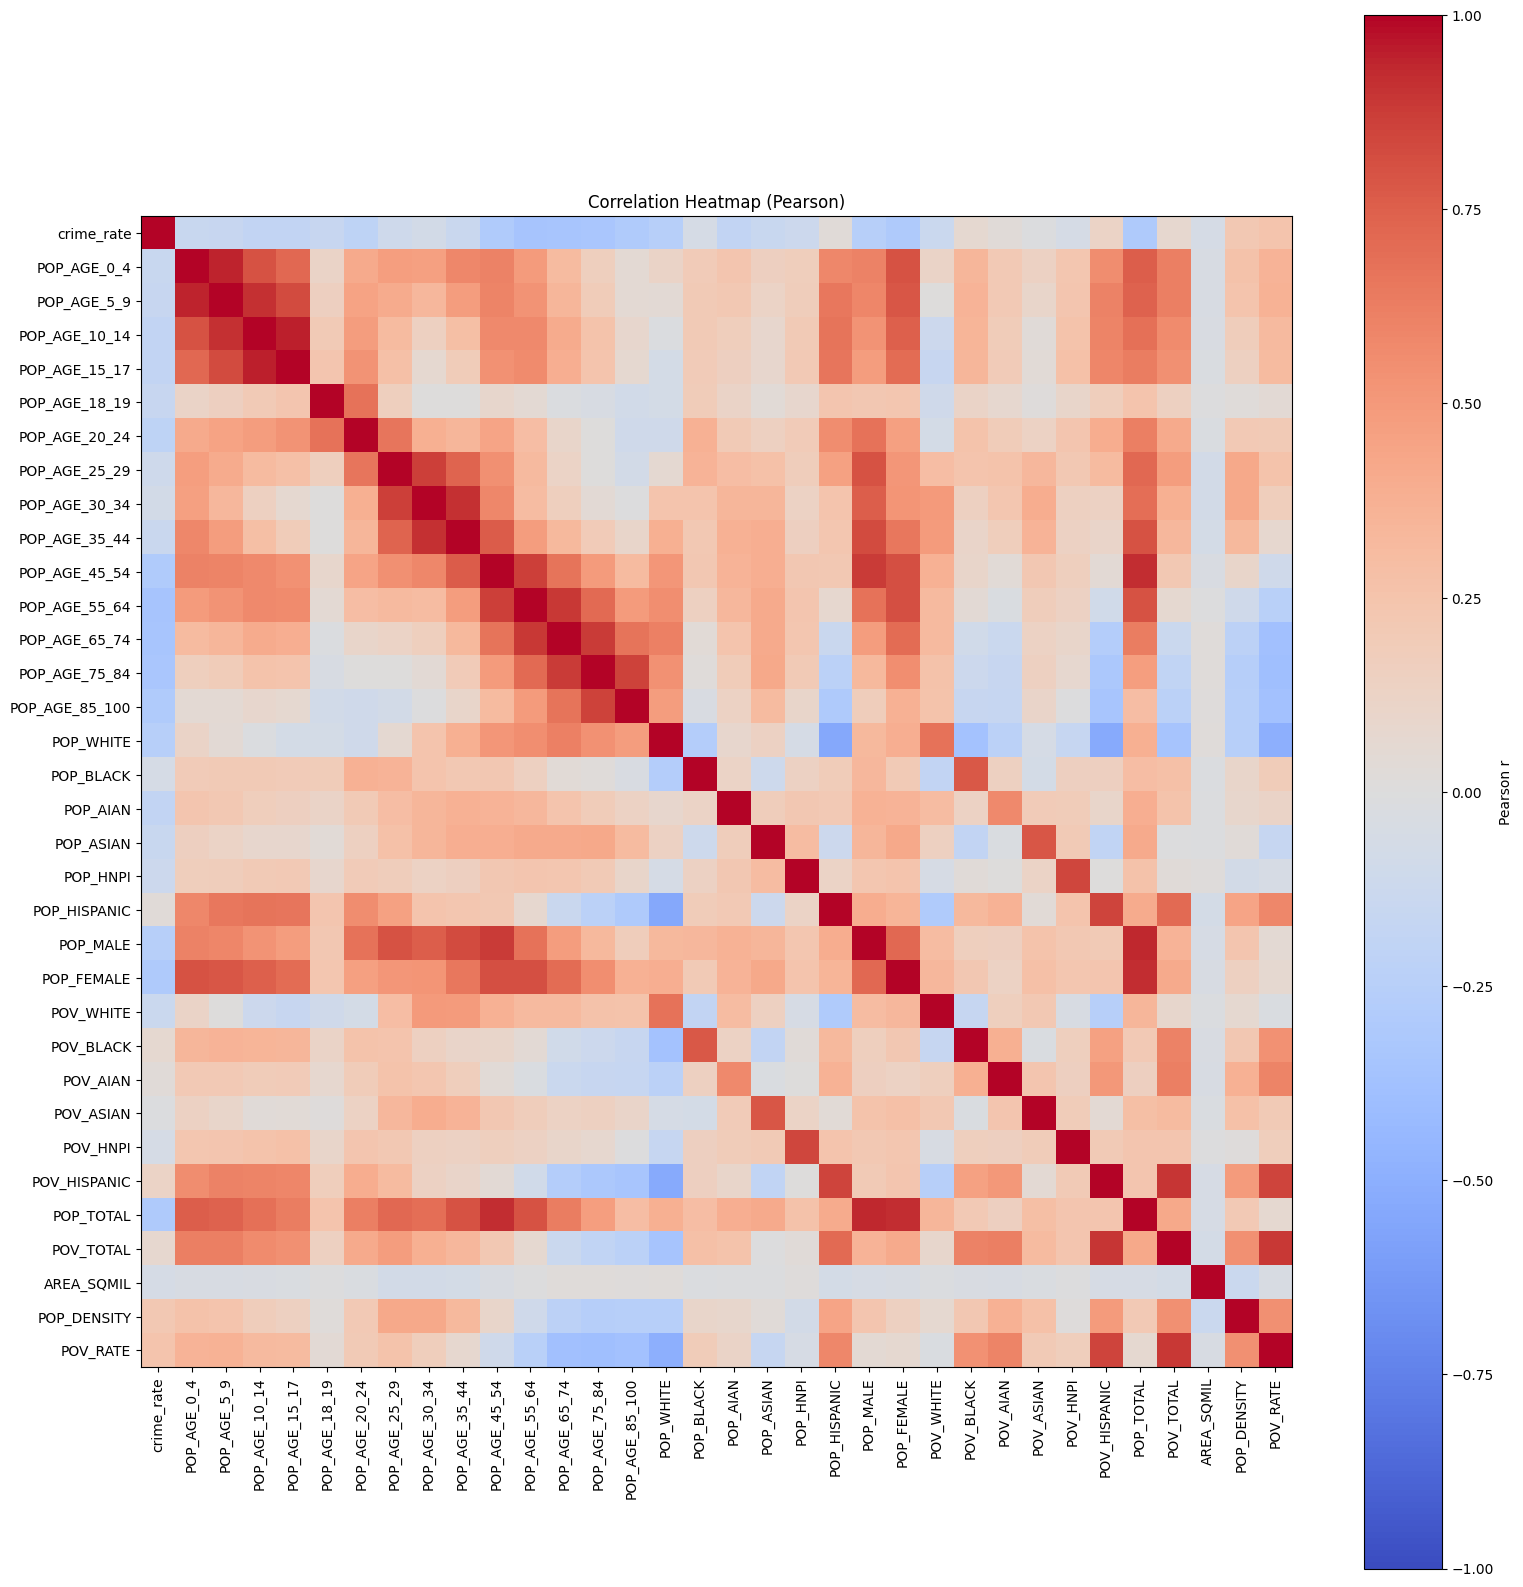

 Variance Inflation Factors (VIF):


,feature,VIF
1,POP_AGE_0_4,inf
14,POP_AGE_85_100,inf
27,POV_HNPI,inf
26,POV_ASIAN,inf
25,POV_AIAN,inf
24,POV_BLACK,inf
23,POV_WHITE,inf
22,POP_FEMALE,inf
21,POP_MALE,inf
30,POV_TOTAL,inf



 OLS Regression (Standardized):
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.185
Model:                            OLS   Adj. R-squared:                  0.184
Method:                 Least Squares   F-statistic:                     125.9
Date:                Fri, 14 Nov 2025   Prob (F-statistic):           1.64e-73
Time:                        05:23:17   Log-Likelihood:                -2194.7
No. Observations:                1667   AIC:                             4397.
Df Residuals:                    1663   BIC:                             4419.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.099e-

,feature,std_coef
0,const,-1.099381e-16
1,POV_RATE,1.547421e-01
2,POP_DENSITY,2.022371e-01
3,POP_TOTAL,-3.500061e-01



 Lasso selected 10 / 33 features


,0
POP_AGE_20_24,-658.590880
POP_DENSITY,524.747473
POV_RATE,512.098176
POP_FEMALE,-427.092508
POP_AGE_85_100,-390.900407
POP_AIAN,-300.198310
POP_AGE_55_64,-192.818287
POP_AGE_75_84,-175.948653
POP_WHITE,-27.030379
AREA_SQMIL,-2.417860


Random Forest Feature Importance:


,0
POP_AGE_55_64,0.105221
AREA_SQMIL,0.095768
POP_AGE_75_84,0.064945
POP_AGE_65_74,0.063461
POP_BLACK,0.054409
POP_WHITE,0.050720
POP_AIAN,0.039348
POP_DENSITY,0.038391
POP_ASIAN,0.036706
POP_AGE_85_100,0.034128


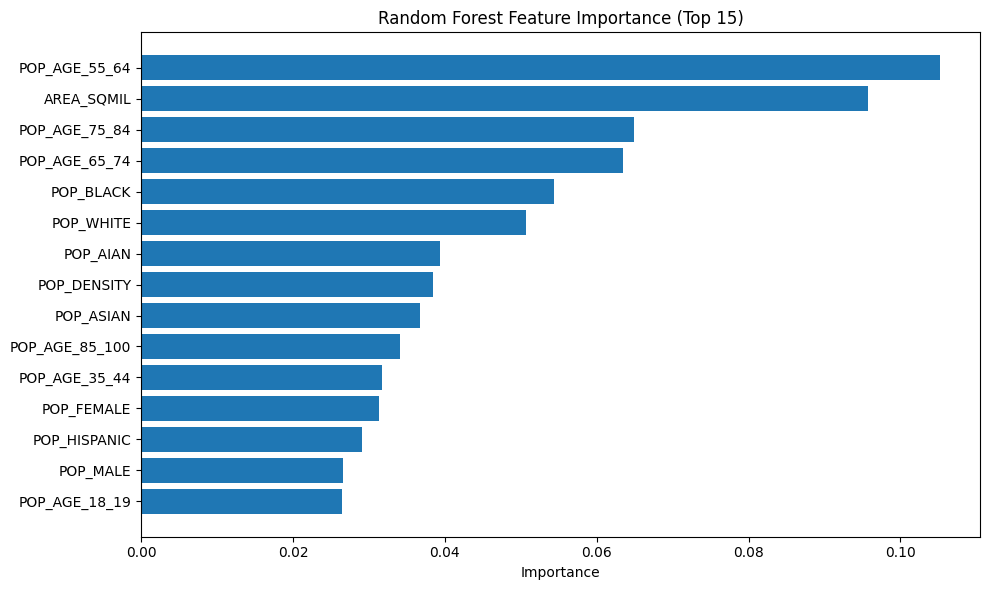

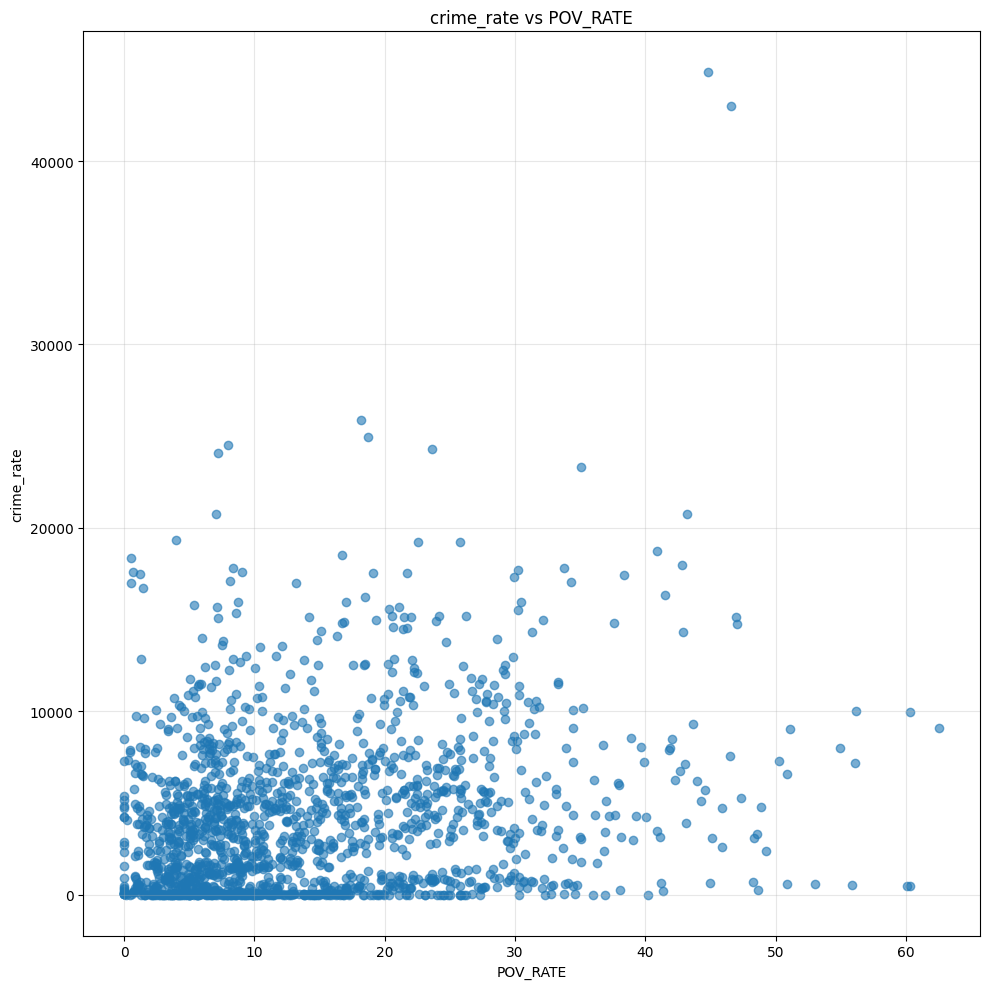

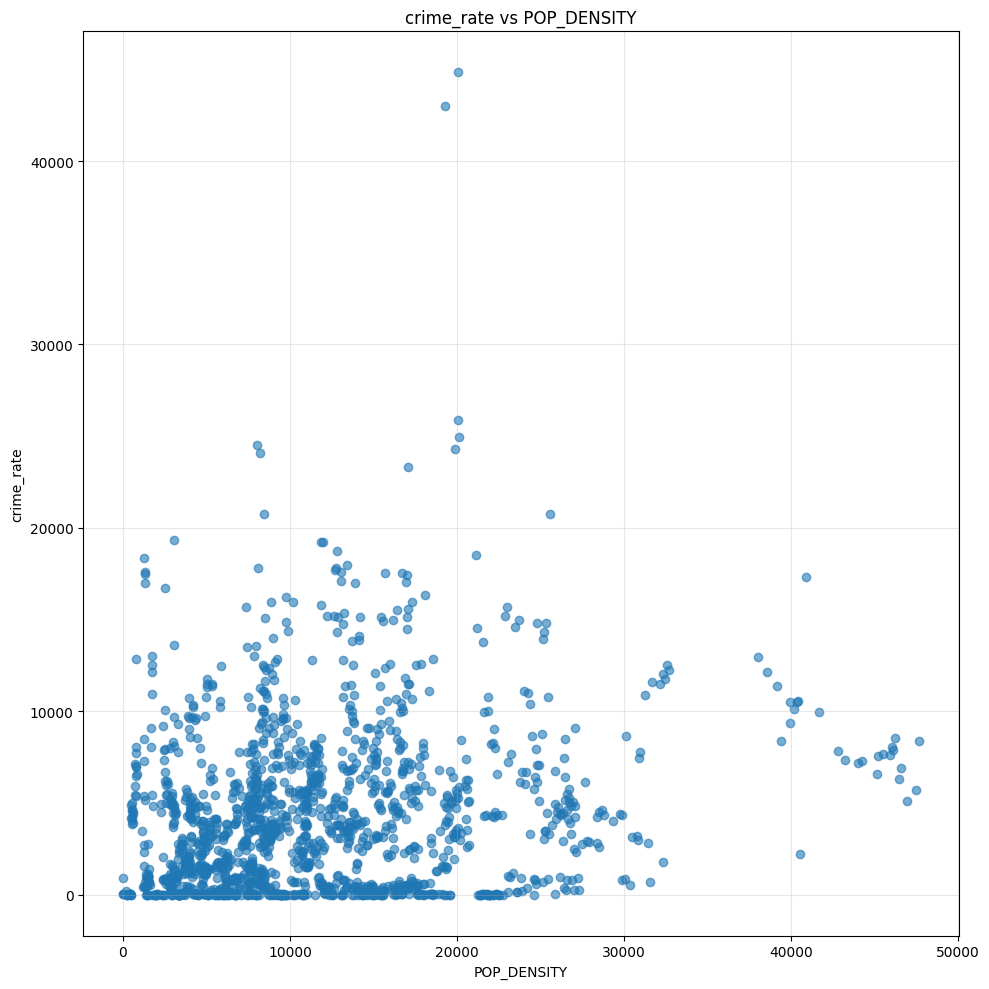

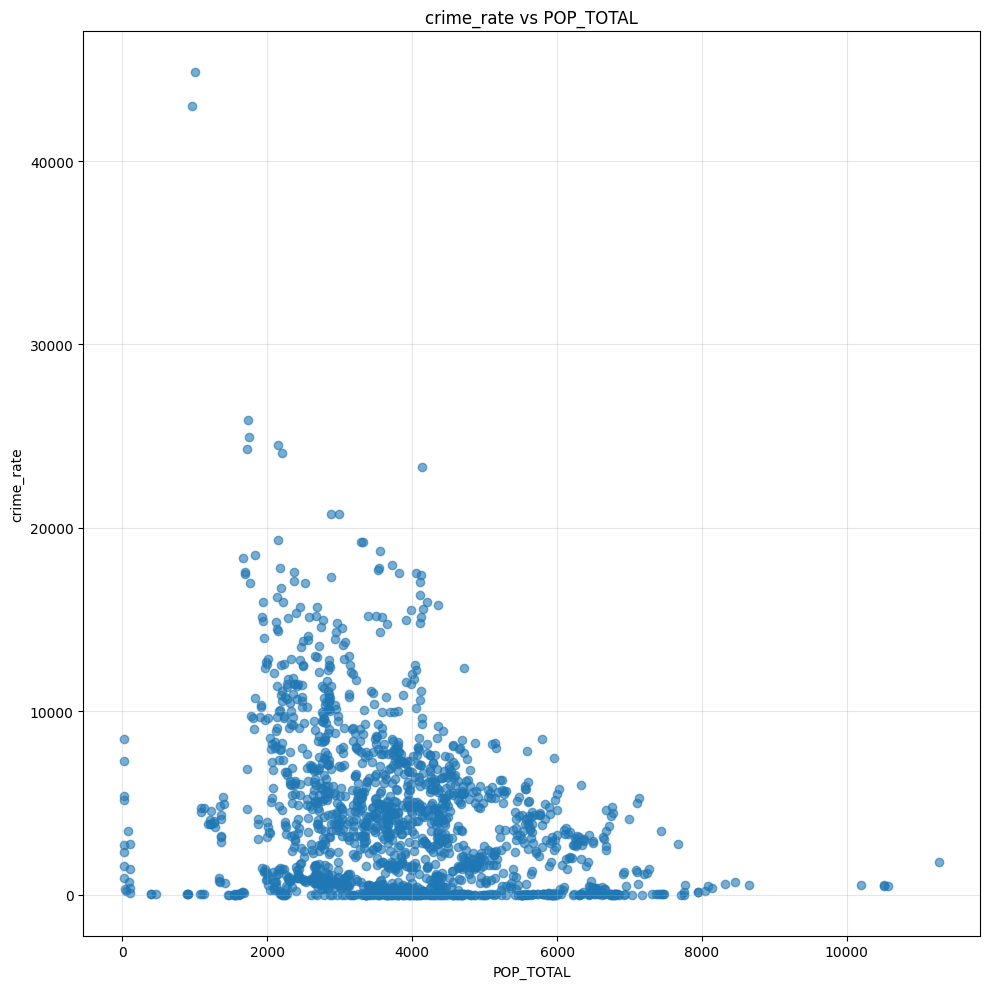


 Summary Takeaways:
- Poverty rate coefficient: +0.155 (↑ poverty → ↑ crime if positive)
- Population density coefficient: +0.202
- Total population coefficient: -0.350
- Check alignment between OLS, Lasso, and RF importances for robust predictors.


In [8]:
# ============================================
#  Which factors influence crime rate? (ZCTA × YEAR)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor

# --------------------------------------------
# 1) Build ZCTA × YEAR panel with crime_rate
# --------------------------------------------
def _to_zcta_str(x):
    try:
        xi = int(float(x))
        return f"{xi:05d}"
    except Exception:
        return pd.NA

crime = crime.copy()
pop   = pop.copy()

crime["DATE OCC"] = pd.to_datetime(crime["DATE OCC"], errors="coerce")
crime = crime.dropna(subset=["DATE OCC", "ZCTA"])
crime["ZCTA"] = crime["ZCTA"].apply(_to_zcta_str)
crime = crime[crime["ZCTA"].notna()]
crime["YEAR"] = crime["DATE OCC"].dt.year

pop["ZCTA"] = pop["ZCTA"].apply(_to_zcta_str)
pop["YEAR"] = pd.to_numeric(pop["YEAR"], errors="coerce")

crime_zcta_year = (
    crime.groupby(["ZCTA", "YEAR"])
         .size()
         .reset_index(name="crime_count")
)

panel = crime_zcta_year.merge(pop, on=["ZCTA", "YEAR"], how="left")
panel["POP_TOTAL"] = pd.to_numeric(panel["POP_TOTAL"], errors="coerce")
panel["crime_rate"] = (panel["crime_count"] / panel["POP_TOTAL"]) * 10000

print(" Panel preview (ZCTA × YEAR):")
display(panel.head())

# --------------------------------------------
# 2) Feature selection and cleaning
# --------------------------------------------
exclude_cols = {
    "OBJECTID","CT","FIP","CITY","SPA","SPA_NAME","HD","HD_NAME",
    "SHAPE__AREA","SHAPE__LENGTH","GEOID","ZCTA_YEAR_KEY",
    "ZCTA","YEAR","crime_count","crime_rate"
}

num_cols = panel.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in num_cols if c not in exclude_cols]
for must in ["POV_RATE","POP_DENSITY","POP_TOTAL"]:
    if must in panel.columns and must not in feature_cols:
        feature_cols.append(must)

model_df = panel[["ZCTA","YEAR","crime_rate"] + feature_cols].dropna(subset=["crime_rate"]).copy()
model_df = model_df[model_df["POP_TOTAL"] > 0]

def _winsorize(df, col, upper_q=0.99):
    uq = df[col].quantile(upper_q)
    return df[df[col] <= uq]

if "POP_DENSITY" in model_df.columns:
    model_df = _winsorize(model_df, "POP_DENSITY", 0.99)
model_df = _winsorize(model_df, "crime_rate", 0.99)

print(f" Cleaned rows: {len(model_df):,}")

# --------------------------------------------
# 3) Correlation analysis
# --------------------------------------------
corr_vars = ["crime_rate"] + [c for c in feature_cols if c in model_df.columns]
corr_mat = model_df[corr_vars].corr(method="pearson")
print(" Pearson correlation (subset):")
display(corr_mat[["crime_rate"]].sort_values(by="crime_rate", ascending=False))

plt.figure(figsize=(16,16))
plt.imshow(corr_mat.values, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Pearson r")
plt.xticks(range(len(corr_mat.columns)), corr_mat.columns, rotation=90)
plt.yticks(range(len(corr_mat.index)), corr_mat.index)
plt.title("Correlation Heatmap (Pearson)")
plt.tight_layout()
plt.show()

# --------------------------------------------
# 4) Multicollinearity check (VIF)
# --------------------------------------------
X_vif = model_df[feature_cols].select_dtypes(include=[np.number]).fillna(0)
X_vif = X_vif.loc[:, X_vif.std() > 0]
X_vif_const = sm.add_constant(X_vif, has_constant='add')

vif_df = pd.DataFrame({
    "feature": X_vif_const.columns,
    "VIF": [variance_inflation_factor(X_vif_const.values, i) for i in range(X_vif_const.shape[1])]
})
vif_df = vif_df[vif_df["feature"] != "const"].sort_values("VIF", ascending=False)
print(" Variance Inflation Factors (VIF):")
display(vif_df.head(10))

# --------------------------------------------
# 5) OLS regression (standardized coefficients)
# --------------------------------------------
base_features = [c for c in ["POV_RATE","POP_DENSITY","POP_TOTAL"] if c in model_df.columns]
if not base_features:
    base_features = corr_mat["crime_rate"].drop("crime_rate").abs().sort_values(ascending=False).head(5).index.tolist()

df_ols = model_df[["crime_rate"] + base_features].dropna().copy()

scalerX = StandardScaler()
X_std = scalerX.fit_transform(df_ols[base_features])
y_std = StandardScaler().fit_transform(df_ols[["crime_rate"]]).ravel()

X_std_const = sm.add_constant(X_std, has_constant='add')
ols_res = sm.OLS(y_std, X_std_const).fit()

print("\n OLS Regression (Standardized):")
print(ols_res.summary())

coef_tbl = pd.DataFrame({
    "feature": ["const"] + base_features,
    "std_coef": ols_res.params
})
display(coef_tbl)

# --------------------------------------------
# 6) Lasso feature selection
# --------------------------------------------
X_full = model_df[feature_cols].select_dtypes(include=[np.number]).fillna(0)
y_full = model_df["crime_rate"].values
scaler = StandardScaler()
X_full_std = scaler.fit_transform(X_full)

lasso = LassoCV(cv=5, random_state=42).fit(X_full_std, y_full)
lasso_coef = pd.Series(lasso.coef_, index=X_full.columns).sort_values(key=np.abs, ascending=False)

print(f"\n Lasso selected {np.sum(lasso_coef!=0)} / {len(lasso_coef)} features")
display(lasso_coef[lasso_coef!=0].head(15))

# --------------------------------------------
# 7) Random Forest (nonlinear importance)
# --------------------------------------------
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=2
)
rf.fit(X_full, y_full)
rf_imp = pd.Series(rf.feature_importances_, index=X_full.columns).sort_values(ascending=False)

print("Random Forest Feature Importance:")
display(rf_imp.head(15))

plt.figure(figsize=(10,6))
plt.barh(rf_imp.head(15).index[::-1], rf_imp.head(15).values[::-1])
plt.title("Random Forest Feature Importance (Top 15)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# --------------------------------------------
# 8) Key relationships (scatter plots)
# --------------------------------------------
def _scatter_xy(df, x, y="crime_rate"):
    plt.figure(figsize=(10,10))
    plt.scatter(df[x], df[y], alpha=0.6)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{y} vs {x}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

for v in ["POV_RATE","POP_DENSITY","POP_TOTAL"]:
    if v in model_df.columns:
        _scatter_xy(model_df, v)

# --------------------------------------------
# 9) Summary takeaway
# --------------------------------------------
print("\n Summary Takeaways:")
if "POV_RATE" in coef_tbl["feature"].values:
    beta_pov = float(coef_tbl.loc[coef_tbl["feature"]=="POV_RATE","std_coef"])
    print(f"- Poverty rate coefficient: {beta_pov:+.3f} (↑ poverty → ↑ crime if positive)")
if "POP_DENSITY" in coef_tbl["feature"].values:
    beta_den = float(coef_tbl.loc[coef_tbl["feature"]=="POP_DENSITY","std_coef"])
    print(f"- Population density coefficient: {beta_den:+.3f}")
if "POP_TOTAL" in coef_tbl["feature"].values:
    beta_tot = float(coef_tbl.loc[coef_tbl["feature"]=="POP_TOTAL","std_coef"])
    print(f"- Total population coefficient: {beta_tot:+.3f}")
print("- Check alignment between OLS, Lasso, and RF importances for robust predictors.")


# ============================================
#  un comment if want Save all images & download (Colab)
# ============================================

# import os
# from google.colab import files

# # 1) Create a folder for all images
# img_dir = "figures"
# os.makedirs(img_dir, exist_ok=True)

# # 2) Recreate & save: Correlation Heatmap (Pearson)
# plt.figure(figsize=(16,16))
# plt.imshow(corr_mat.values, cmap="coolwarm", vmin=-1, vmax=1)
# plt.colorbar(label="Pearson r")
# plt.xticks(range(len(corr_mat.columns)), corr_mat.columns, rotation=90)
# plt.yticks(range(len(corr_mat.index)), corr_mat.index)
# plt.title("Correlation Heatmap (Pearson)")
# plt.tight_layout()
# plt.savefig(os.path.join(img_dir, "Correlation_Heatmap_Pearson.png"),
#             dpi=300, bbox_inches="tight")
# plt.show()

# # 3) Recreate & save: Random Forest Feature Importance (Top 15)
# plt.figure(figsize=(10,10))
# plt.barh(rf_imp.head(15).index[::-1], rf_imp.head(15).values[::-1])
# plt.title("Random Forest Feature Importance (Top 15)")
# plt.xlabel("Importance")
# plt.tight_layout()
# plt.savefig(os.path.join(img_dir, "Random_Forest_Feature_Importance_Top15.png"),
#             dpi=300, bbox_inches="tight")
# plt.show()

# # 4) Recreate & save: Scatter plots vs crime_rate
# for v in ["POV_RATE", "POP_DENSITY", "POP_TOTAL"]:
#     if v in model_df.columns:
#         plt.figure(figsize=(10,10))
#         plt.scatter(model_df[v], model_df["crime_rate"], alpha=0.6)
#         plt.xlabel(v)
#         plt.ylabel("crime_rate")
#         plt.title(f"crime_rate vs {v}")
#         plt.grid(alpha=0.3)
#         plt.tight_layout()
#         fname = f"crime_rate_vs_{v}.png"
#         plt.savefig(os.path.join(img_dir, fname),
#                     dpi=300, bbox_inches="tight")
#         plt.show()

# print("Saved all images to folder:", img_dir)

# # 5) Zip the folder and download it (Colab)
# !zip -r figures.zip figures
# files.download("figures.zip")


panel[["POV_RATE","POP_DENSITY"]].corr(method="pearson")

Summary

r = 0.55 → moderately strong positive correlation.

VIF ≈ 1.4 → no multicollinearity concern.

Interpretation: Denser ZIPs often poorer, but not all; both independently explain crime rate variation.

In [9]:
# ============================================
#  Add Older Population Percentage (≥55) to pop DataFrame
# ============================================

# Make a copy to avoid modifying original by reference
pop = pop.copy()

# Define columns representing age groups ≥55
age_cols_55p = ["POP_AGE_55_64", "POP_AGE_65_74", "POP_AGE_75_84", "POP_AGE_85_100"]

# Handle missing columns safely (if any column doesn't exist, create with 0)
for c in age_cols_55p:
    if c not in pop.columns:
        pop[c] = 0

# Compute OLD_PCT = (population aged ≥55 / total population) * 100
pop["OLD_PCT"] = (
    pop[age_cols_55p].sum(axis=1) / pop["POP_TOTAL"]
) * 100

# Preview the result
print("Added column: OLD_PCT (percent of population aged ≥55)")
display(pop[["ZCTA", "YEAR", "POP_TOTAL", "OLD_PCT"]].head())


Added column: OLD_PCT (percent of population aged ≥55)


,ZCTA,YEAR,POP_TOTAL,OLD_PCT
0,91042,2013,4767,27.501573
1,91352,2013,1781,33.576642
2,91504,2013,3698,31.422390
3,91040,2013,2713,31.109473
4,91342,2013,4205,20.594530


 Pearson Correlation Matrix:


,OLD_PCT,POP_TOTAL,POV_RATE,POP_DENSITY
OLD_PCT,1.000000,-0.227015,-0.503854,-0.389234
POP_TOTAL,-0.227015,1.000000,0.080749,0.151952
POV_RATE,-0.503854,0.080749,1.000000,0.515494
POP_DENSITY,-0.389234,0.151952,0.515494,1.000000


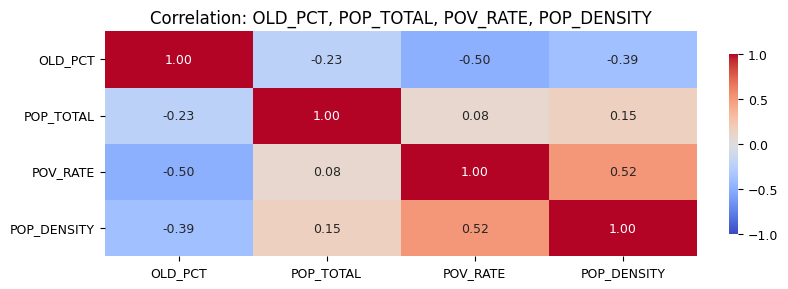

In [10]:
# ============================================
#  Correlation among OLD_PCT, POP_TOTAL, POV_RATE, POP_DENSITY
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Keep only the needed numeric columns
corr_cols = ["OLD_PCT", "POP_TOTAL", "POV_RATE", "POP_DENSITY"]

# Drop missing values to ensure valid correlation computation
pop_corr = pop[corr_cols].dropna()

# Compute correlation matrix (Pearson by default)
corr_matrix = pop_corr.corr(method="pearson")

print(" Pearson Correlation Matrix:")
display(corr_matrix)

# --- Visualize as heatmap ---

# ---------- Universal sizing ----------
FS_TITLE = 12
FS_AXIS  = 10   # axis label size (if you set any)
FS_TICK  = 9    # x/y tick labels
FS_ANNOT = 9    # numbers inside cells
FS_CBAR  = 9    # colorbar tick labels

plt.figure(figsize=(8,3))  # rectangular
ax = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    square=False,
    annot_kws={"size": FS_ANNOT},
    cbar=True,
    cbar_kws={"shrink": 0.8, "fraction": 0.04, "pad": 0.05}
)

# Title
plt.title("Correlation: OLD_PCT, POP_TOTAL, POV_RATE, POP_DENSITY", fontsize=FS_TITLE)

# Tick labels (horizontal) and size
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha="center", fontsize=FS_TICK)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, va="center", fontsize=FS_TICK)

# Axis labels (optional; keep if you set them)
ax.set_xlabel("", fontsize=FS_AXIS)
ax.set_ylabel("", fontsize=FS_AXIS)

# Colorbar tick size
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=FS_CBAR)

ax.set_aspect("auto")
plt.tight_layout()
plt.show()


# ---- Save figure as PNG ----
# filename = "Correlation_OLD_PCT_POP_TOTAL_POV_RATE_POP_DENSITY.png"
# plt.savefig(filename, dpi=300, bbox_inches="tight")

# plt.show()
# print("Saved image as:", filename)

# # ---- (Optional) auto-download in Google Colab ----
# try:
#     from google.colab import files
#     files.download(filename)
# except ImportError:
#     # Not running in Colab
#     pass


In [11]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = pop[["OLD_PCT", "POP_TOTAL", "POV_RATE", "POP_DENSITY"]].dropna()
X = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
display(vif_data)


,feature,VIF
0,const,29.669879
1,OLD_PCT,1.439290
2,POP_TOTAL,1.065640
3,POV_RATE,1.606671
4,POP_DENSITY,1.417702


The correlation matrix tells us
Pair	Correlation	Meaning
OLD_PCT ↔ POV_RATE	-0.50	Areas with older populations tend to have lower poverty rates.
POV_RATE ↔ POP_DENSITY	+0.52	Denser areas tend to have higher poverty rates.
OLD_PCT ↔ POP_DENSITY	-0.39	Older populations are more common in less dense areas (suburbs).
OLD_PCT ↔ POP_TOTAL	-0.23	Mild negative — smaller ZCTAs or suburban areas have older residents.
POP_TOTAL ↔ others	Low correlation → can keep safely.

Interpretation:
There’s moderate correlation (0.4–0.5) between several of these factors → not severe multicollinearity, but possibly redundant information if you include all.

All predictor VIF values are well below 5, which means no multicollinearity problems.

PCA is not needed here — it wouldn’t add much benefit and would actually reduce interpretability.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 Model fitted successfully — SARIMAX (Population + Pandemic)
                                     SARIMAX Results                                      
Dep. Variable:                        crime_count   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -751.099
Date:                            Fri, 14 Nov 2025   AIC                           1522.198
Time:                                    05:23:36   BIC                           1547.524
Sample:                                01-31-2013   HQIC                          1532.424
                                     - 12-31-2022                                         
Covariance Type:                              opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
POP_TOTAL      -0.3689      0.151     -2.444      0

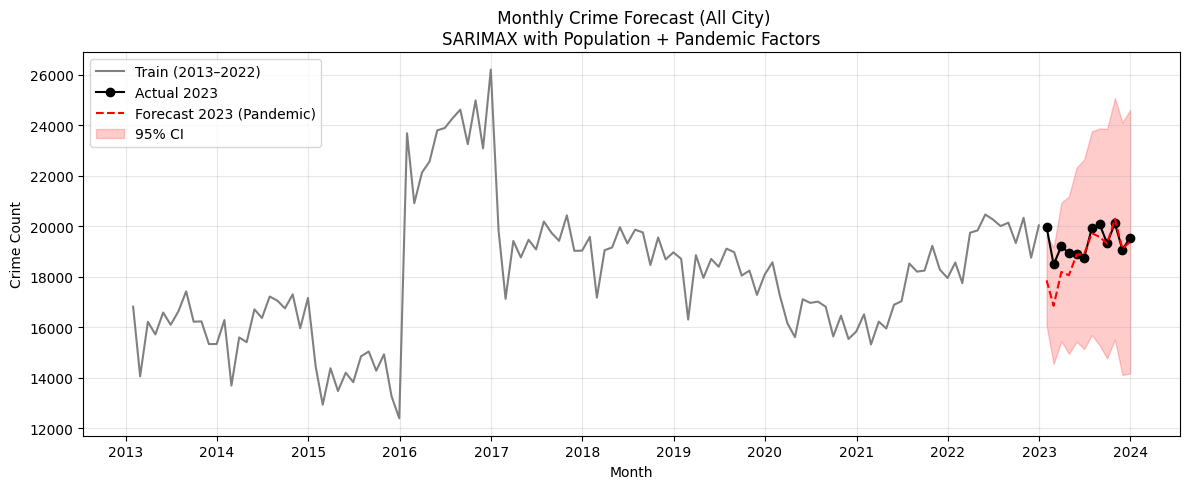


 Model Performance (SARIMAX + Pandemic):
mae_SARIMAX_PANDEMIC_Pop  : 577
rmse_SARIMAX_PANDEMIC_Pop : 881
aic_SARIMAX_PANDEMIC_Pop  : 1,522.20
bic_SARIMAX_PANDEMIC_Pop  : 1,547.52


In [12]:
# ============================================
#  MONTHLY CRIME FORECASTING (ALL CITY) — WITH POPULATION & PANDEMIC
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- Prepare data ---
crime["DATE OCC"] = pd.to_datetime(crime["DATE OCC"], errors="coerce")

crime_monthly = (
    crime.groupby(pd.Grouper(key="DATE OCC", freq="M"))
         .size()
         .reset_index(name="crime_count")
         .rename(columns={"DATE OCC": "ds"})
)
crime_monthly["YEAR"] = crime_monthly["ds"].dt.year

pop_yearly = (
    pop.groupby("YEAR", as_index=False)
       .agg({
           "POP_TOTAL": "sum",
           "POV_RATE": "mean",
           "POP_DENSITY": "mean",
           "OLD_PCT": "mean"
       })
)

crime_pop = crime_monthly.merge(pop_yearly, on="YEAR", how="left").sort_values("ds")
crime_pop = crime_pop.set_index("ds")

years = crime_pop.index.year
crime_pop["pandemic"] = ((years >= 2020) & (years <= 2023)).astype(int)

train = crime_pop.loc[crime_pop.index.year <= 2022]
test  = crime_pop.loc[crime_pop.index.year == 2023]

exog_cols = ["POP_TOTAL", "POV_RATE", "POP_DENSITY", "OLD_PCT", "pandemic"]
exog_train = train[exog_cols]
exog_test  = test[exog_cols]

# --- Fit model (named) ---
SARIMAX_PANDEMIC_NAME = "SARIMAX (Population + Pandemic)"
SARIMAX_PANDEMIC_POP = SARIMAX(
    train["crime_count"],
    exog=exog_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
res_pandemic = SARIMAX_PANDEMIC_POP.fit(disp=False)

print(f" Model fitted successfully — {SARIMAX_PANDEMIC_NAME}")
print(res_pandemic.summary())

# --- Forecast 2023 ---
pred_pandemic = res_pandemic.get_forecast(steps=len(test), exog=exog_test)
pred_df_pandemic = pred_pandemic.summary_frame()
pred_df_pandemic["actual"] = test["crime_count"].values

# --- Plot ---
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(train.index, train["crime_count"], label="Train (2013–2022)", color="gray")
ax.plot(test.index, test["crime_count"], "o-", label="Actual 2023", color="black")
ax.plot(test.index, pred_df_pandemic["mean"], "r--", label="Forecast 2023 (Pandemic)")
ax.fill_between(test.index, pred_df_pandemic["mean_ci_lower"], pred_df_pandemic["mean_ci_upper"],
                color="red", alpha=0.2, label="95% CI")
ax.set_title(" Monthly Crime Forecast (All City)\nSARIMAX with Population + Pandemic Factors")
ax.set_xlabel("Month"); ax.set_ylabel("Crime Count")
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

# --- Metrics (renamed as requested) ---
mae_SARIMAX_PANDEMIC_Pop  = mean_absolute_error(test["crime_count"], pred_df_pandemic["mean"])
rmse_SARIMAX_PANDEMIC_Pop = np.sqrt(mean_squared_error(test["crime_count"], pred_df_pandemic["mean"]))
aic_SARIMAX_PANDEMIC_Pop  = res_pandemic.aic
bic_SARIMAX_PANDEMIC_Pop  = res_pandemic.bic

print("\n Model Performance (SARIMAX + Pandemic):")
print(f"mae_SARIMAX_PANDEMIC_Pop  : {mae_SARIMAX_PANDEMIC_Pop:,.0f}")
print(f"rmse_SARIMAX_PANDEMIC_Pop : {rmse_SARIMAX_PANDEMIC_Pop:,.0f}")
print(f"aic_SARIMAX_PANDEMIC_Pop  : {aic_SARIMAX_PANDEMIC_Pop:,.2f}")
print(f"bic_SARIMAX_PANDEMIC_Pop  : {bic_SARIMAX_PANDEMIC_Pop:,.2f}")


 Combined dataset (population only, no pandemic):


,crime_count,YEAR,POP_TOTAL,POV_RATE,POP_DENSITY,OLD_PCT
ds,,,,,,
2013-01-31,16817,2013,1128952,14.490197,9084.836238,26.020091
2013-02-28,14062,2013,1128952,14.490197,9084.836238,26.020091
2013-03-31,16218,2013,1128952,14.490197,9084.836238,26.020091
2013-04-30,15719,2013,1128952,14.490197,9084.836238,26.020091
2013-05-31,16587,2013,1128952,14.490197,9084.836238,26.020091


Train period: 2013-01-31 → 2022-12-31
Test  period: 2023-01-31 → 2023-12-31


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


 Model fitted successfully — SARIMAX (Population Only)
                                     SARIMAX Results                                      
Dep. Variable:                        crime_count   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -751.031
Date:                            Fri, 14 Nov 2025   AIC                           1520.063
Time:                                    05:23:43   BIC                           1542.856
Sample:                                01-31-2013   HQIC                          1529.266
                                     - 12-31-2022                                         
Covariance Type:                              opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
POP_TOTAL      -0.3694      0.117     -3.153      0.002  

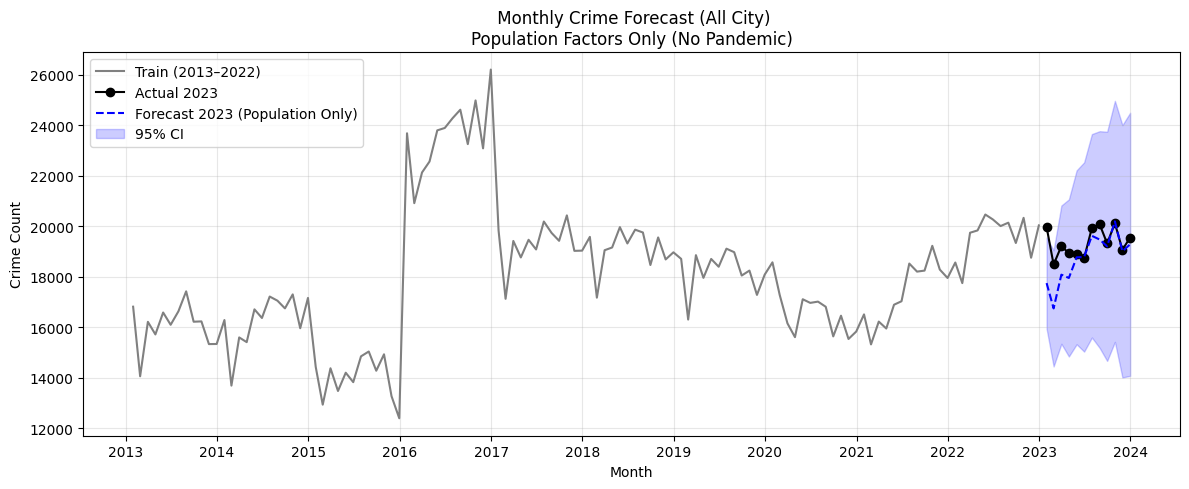


 Model performance on 2023 — SARIMAX (Population Only):
mae_SARIMAX_POP_NAME  : 640
rmse_SARIMAX_POP_NAME : 947
aic_SARIMAX_POP_NAME  : 1,520.06
bic_SARIMAX_POP_NAME  : 1,542.86

Model coefficients (population only):
POP_TOTAL          -0.369370
POV_RATE        -2326.654026
POP_DENSITY        17.919886
OLD_PCT          5989.783930
ar.L1              -0.167800
ma.L1              -0.044014
ar.S.L12           -0.635876
ma.S.L12            0.017749
sigma2         847814.962624
dtype: float64

 Interpretation:
- POP_TOTAL    → population size impact on total crime.
- POV_RATE     → socioeconomic factor; higher poverty may increase crime.
- POP_DENSITY  → crowding and urbanization effect.
- OLD_PCT      → older population share (often negative impact on crime).


In [13]:
# ============================================
#  MONTHLY CRIME FORECASTING (ALL CITY) — POPULATION ONLY (NO PANDEMIC)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --------------------------------------------
#  Step 1. Prepare monthly crime and population data
# --------------------------------------------
# 1.1 Ensure datetime
crime["DATE OCC"] = pd.to_datetime(crime["DATE OCC"], errors="coerce")

# 1.2 Aggregate monthly total crime count
crime_monthly = (
    crime.groupby(pd.Grouper(key="DATE OCC", freq="M"))
         .size()
         .reset_index(name="crime_count")
         .rename(columns={"DATE OCC": "ds"})
)
crime_monthly["YEAR"] = crime_monthly["ds"].dt.year

# 1.3 Aggregate population data per year (including older percentage)
pop_yearly = (
    pop.groupby("YEAR", as_index=False)
       .agg({
           "POP_TOTAL": "sum",
           "POV_RATE": "mean",
           "POP_DENSITY": "mean",
           "OLD_PCT": "mean"
       })
)

# 1.4 Merge population factors into monthly crime data
crime_pop = crime_monthly.merge(pop_yearly, on="YEAR", how="left")
crime_pop = crime_pop.sort_values("ds").set_index("ds")

print(" Combined dataset (population only, no pandemic):")
display(crime_pop.head())

# --------------------------------------------
#  Step 2. Split into train (<=2022) and test (2023)
# --------------------------------------------
train = crime_pop.loc[crime_pop.index.year <= 2022]
test  = crime_pop.loc[crime_pop.index.year == 2023]

exog_cols = ["POP_TOTAL", "POV_RATE", "POP_DENSITY", "OLD_PCT"]
exog_train = train[exog_cols]
exog_test  = test[exog_cols]

print(f"Train period: {train.index.min().date()} → {train.index.max().date()}")
print(f"Test  period: {test.index.min().date()} → {test.index.max().date()}")

# --------------------------------------------
#  Step 3. Fit SARIMAX model (Population Only)
# --------------------------------------------
SARIMAX_POP_NAME = "SARIMAX (Population Only)"
SARIMAX_POP_ONLY = SARIMAX(
    train["crime_count"],
    exog=exog_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
res_pop = SARIMAX_POP_ONLY.fit(disp=False)

print(f" Model fitted successfully — {SARIMAX_POP_NAME}")
print(res_pop.summary())

# --------------------------------------------
#  Step 4. Forecast 2023
# --------------------------------------------
pred_SARIMAX_POP = res_pop.get_forecast(steps=len(test), exog=exog_test)
pred_df_SARIMAX_POP = pred_SARIMAX_POP.summary_frame()
pred_df_SARIMAX_POP["actual"] = test["crime_count"].values

# --------------------------------------------
#  Step 5. Visualize actual vs forecast
# --------------------------------------------
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(train.index, train["crime_count"], label="Train (2013–2022)", color="gray")
ax.plot(test.index, test["crime_count"], "o-", label="Actual 2023", color="black")
ax.plot(test.index, pred_df_SARIMAX_POP["mean"], "b--", label="Forecast 2023 (Population Only)")
ax.fill_between(test.index,
                pred_df_SARIMAX_POP["mean_ci_lower"],
                pred_df_SARIMAX_POP["mean_ci_upper"],
                color="blue", alpha=0.2, label="95% CI")
ax.set_title(" Monthly Crime Forecast (All City)\nPopulation Factors Only (No Pandemic)")
ax.set_xlabel("Month")
ax.set_ylabel("Crime Count")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --------------------------------------------
#  Step 6. Evaluate model performance (named uniquely)
# --------------------------------------------
mae_SARIMAX_POP_NAME  = mean_absolute_error(test["crime_count"], pred_df_SARIMAX_POP["mean"])
rmse_SARIMAX_POP_NAME = np.sqrt(mean_squared_error(test["crime_count"], pred_df_SARIMAX_POP["mean"]))
aic_SARIMAX_POP_NAME  = res_pop.aic
bic_SARIMAX_POP_NAME  = res_pop.bic

print(f"\n Model performance on 2023 — {SARIMAX_POP_NAME}:")
print(f"mae_SARIMAX_POP_NAME  : {mae_SARIMAX_POP_NAME:,.0f}")
print(f"rmse_SARIMAX_POP_NAME : {rmse_SARIMAX_POP_NAME:,.0f}")
print(f"aic_SARIMAX_POP_NAME  : {aic_SARIMAX_POP_NAME:,.2f}")
print(f"bic_SARIMAX_POP_NAME  : {bic_SARIMAX_POP_NAME:,.2f}")

# --------------------------------------------
# Step 7. Interpret coefficients
# --------------------------------------------
coef_pop = res_pop.params
print("\nModel coefficients (population only):")
print(coef_pop)

print("\n Interpretation:")
print("- POP_TOTAL    → population size impact on total crime.")
print("- POV_RATE     → socioeconomic factor; higher poverty may increase crime.")
print("- POP_DENSITY  → crowding and urbanization effect.")
print("- OLD_PCT      → older population share (often negative impact on crime).")


Train period: 2013-01-31 → 2022-12-31
Test  period: 2023-01-31 → 2023-12-31

 Model Performance — PROPHET (Population Only):
mae_PROPHET_POP_NAME  : 2,239
rmse_PROPHET_POP_NAME : 2,295


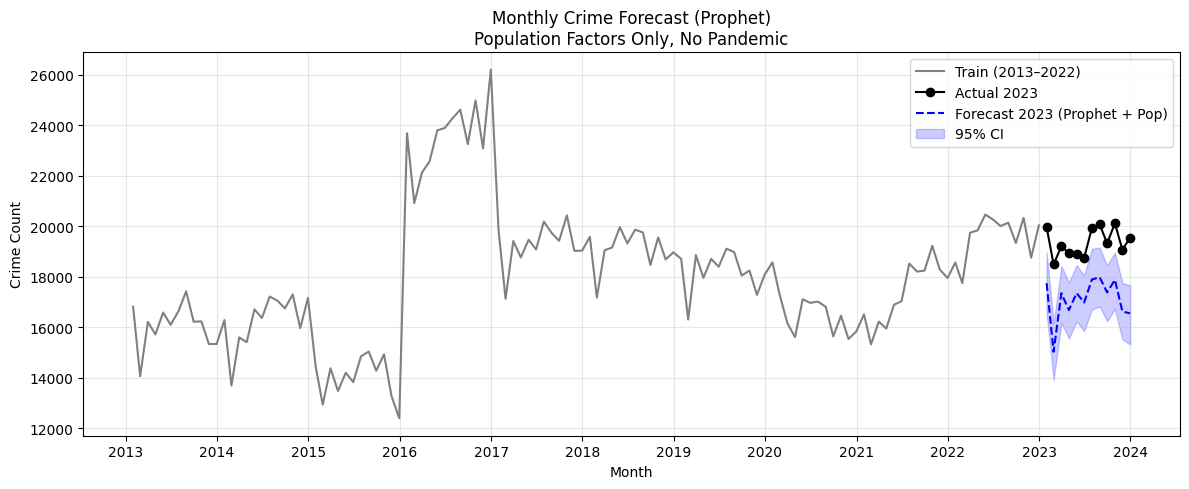

In [14]:
# ============================================
# PROPHET (Population Only) — Monthly Citywide Crime Forecast
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- Install Prophet if needed ---
try:
    from prophet import Prophet
except Exception:
    !pip -q install prophet
    from prophet import Prophet

# --------------------------------------------
# Step 1. Prepare monthly crime + population data
# --------------------------------------------
crime_work = crime.copy()
crime_work["DATE OCC"] = pd.to_datetime(crime_work["DATE OCC"], errors="coerce")

crime_monthly = (
    crime_work.groupby(pd.Grouper(key="DATE OCC", freq="M"))
              .size()
              .reset_index(name="crime_count")
              .rename(columns={"DATE OCC": "ds"})
)
crime_monthly["YEAR"] = crime_monthly["ds"].dt.year

# Yearly population features
pop_yearly = (
    pop.groupby("YEAR", as_index=False)
       .agg({
           "POP_TOTAL": "sum",
           "POV_RATE": "mean",
           "POP_DENSITY": "mean",
           "OLD_PCT": "mean"
       })
)

# Merge with monthly crime data
df = crime_monthly.merge(pop_yearly, on="YEAR", how="left").sort_values("ds")
df = df.set_index("ds")
df_prophet = df.reset_index().rename(columns={"crime_count": "y"})

# --------------------------------------------
#  Step 2. Split train (<=2022) / test (2023)
# --------------------------------------------
train_df = df_prophet[df_prophet["ds"].dt.year <= 2022].copy()
test_df  = df_prophet[df_prophet["ds"].dt.year == 2023].copy()

exog_cols = ["POP_TOTAL", "POV_RATE", "POP_DENSITY", "OLD_PCT"]

print(f"Train period: {train_df['ds'].min().date()} → {train_df['ds'].max().date()}")
print(f"Test  period: {test_df['ds'].min().date()} → {test_df['ds'].max().date()}")

# --------------------------------------------
# Step 3. Fit Prophet model (Population only)
# --------------------------------------------
PROPHET_POP_NAME = "PROPHET (Population Only)"
PROPHET_POP = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive",
    interval_width=0.95
)

# Add regressors
for col in exog_cols:
    PROPHET_POP.add_regressor(col)

PROPHET_POP.fit(train_df[["ds", "y"] + exog_cols])

# --------------------------------------------
#  Step 4. Forecast 2023
# --------------------------------------------
future = test_df[["ds"] + exog_cols].copy()
forecast_POP = PROPHET_POP.predict(future)

# Merge predictions with actuals
pred_df_PROPHET_POP = forecast_POP[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    test_df[["ds", "y"]], on="ds", how="left"
).rename(columns={"y": "actual"})

# --------------------------------------------
# Step 5. Evaluate model performance
# --------------------------------------------
mae_PROPHET_POP_NAME  = mean_absolute_error(pred_df_PROPHET_POP["actual"], pred_df_PROPHET_POP["yhat"])
rmse_PROPHET_POP_NAME = np.sqrt(mean_squared_error(pred_df_PROPHET_POP["actual"], pred_df_PROPHET_POP["yhat"]))

print(f"\n Model Performance — {PROPHET_POP_NAME}:")
print(f"mae_PROPHET_POP_NAME  : {mae_PROPHET_POP_NAME:,.0f}")
print(f"rmse_PROPHET_POP_NAME : {rmse_PROPHET_POP_NAME:,.0f}")

# --------------------------------------------
# Step 6. Plot forecast vs actual
# --------------------------------------------
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(train_df["ds"], train_df["y"], label="Train (2013–2022)", color="gray")
ax.plot(test_df["ds"], test_df["y"], "o-", label="Actual 2023", color="black")
ax.plot(pred_df_PROPHET_POP["ds"], pred_df_PROPHET_POP["yhat"], "b--", label="Forecast 2023 (Prophet + Pop)")
ax.fill_between(pred_df_PROPHET_POP["ds"],
                pred_df_PROPHET_POP["yhat_lower"],
                pred_df_PROPHET_POP["yhat_upper"],
                color="blue", alpha=0.2, label="95% CI")

ax.set_title("Monthly Crime Forecast (Prophet)\nPopulation Factors Only, No Pandemic")
ax.set_xlabel("Month")
ax.set_ylabel("Crime Count")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Train period: 2013-01-31 → 2022-12-31
Test  period: 2023-01-31 → 2023-12-31

 Model Performance — PROPHET (Population + Pandemic):
mae_PROPHET_PANDEMIC_POP_NAME  : 674
rmse_PROPHET_PANDEMIC_POP_NAME : 844


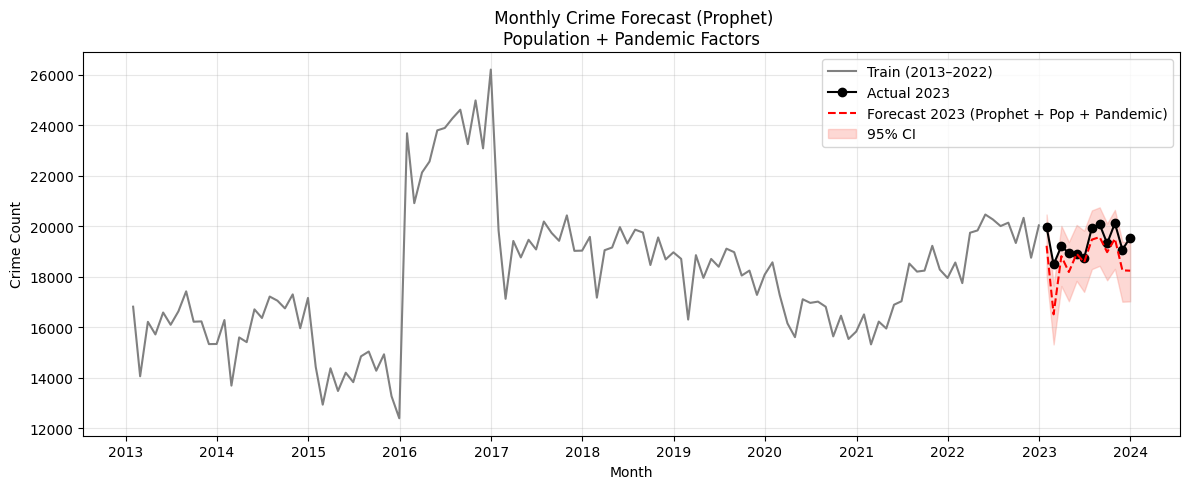

In [15]:
# ============================================
# PROPHET (Population + Pandemic) — Monthly Citywide Crime Forecast
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- Install Prophet if needed ---
try:
    from prophet import Prophet
except Exception:
    !pip -q install prophet
    from prophet import Prophet

# --------------------------------------------
#  Step 1. Prepare monthly crime + population + pandemic data
# --------------------------------------------
crime_work = crime.copy()
crime_work["DATE OCC"] = pd.to_datetime(crime_work["DATE OCC"], errors="coerce")

crime_monthly = (
    crime_work.groupby(pd.Grouper(key="DATE OCC", freq="M"))
              .size()
              .reset_index(name="crime_count")
              .rename(columns={"DATE OCC": "ds"})
)
crime_monthly["YEAR"] = crime_monthly["ds"].dt.year

# Yearly population features (same as before)
pop_yearly = (
    pop.groupby("YEAR", as_index=False)
       .agg({
           "POP_TOTAL": "sum",
           "POV_RATE": "mean",
           "POP_DENSITY": "mean",
           "OLD_PCT": "mean"
       })
)

# Merge with population data
df = crime_monthly.merge(pop_yearly, on="YEAR", how="left").sort_values("ds")

# Add pandemic binary flag (1 for 2020–2023)
df["pandemic"] = df["YEAR"].between(2020, 2023).astype(int)

# Prophet requires ds + y
df = df.set_index("ds")
df_prophet = df.reset_index().rename(columns={"crime_count": "y"})

# --------------------------------------------
#  Step 2. Split into train (<=2022) and test (2023)
# --------------------------------------------
train_df = df_prophet[df_prophet["ds"].dt.year <= 2022].copy()
test_df  = df_prophet[df_prophet["ds"].dt.year == 2023].copy()

exog_cols = ["POP_TOTAL", "POV_RATE", "POP_DENSITY", "OLD_PCT", "pandemic"]

print(f"Train period: {train_df['ds'].min().date()} → {train_df['ds'].max().date()}")
print(f"Test  period: {test_df['ds'].min().date()} → {test_df['ds'].max().date()}")

# --------------------------------------------
# Step 3. Fit Prophet model (Population + Pandemic)
# --------------------------------------------
PROPHET_PANDEMIC_POP_NAME = "PROPHET (Population + Pandemic)"
PROPHET_PANDEMIC_POP = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive",
    interval_width=0.95
)

# Add all regressors (population + pandemic)
for col in exog_cols:
    PROPHET_PANDEMIC_POP.add_regressor(col)

# Fit the model
PROPHET_PANDEMIC_POP.fit(train_df[["ds", "y"] + exog_cols])

# --------------------------------------------
# Step 4. Forecast 2023
# --------------------------------------------
future = test_df[["ds"] + exog_cols].copy()
forecast_PANDEMIC_POP = PROPHET_PANDEMIC_POP.predict(future)

# Merge predictions with actuals
pred_df_PROPHET_PANDEMIC_POP = forecast_PANDEMIC_POP[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    test_df[["ds", "y"]], on="ds", how="left"
).rename(columns={"y": "actual"})

# --------------------------------------------
# Step 5. Evaluate model performance
# --------------------------------------------
mae_PROPHET_PANDEMIC_POP_NAME  = mean_absolute_error(pred_df_PROPHET_PANDEMIC_POP["actual"], pred_df_PROPHET_PANDEMIC_POP["yhat"])
rmse_PROPHET_PANDEMIC_POP_NAME = np.sqrt(mean_squared_error(pred_df_PROPHET_PANDEMIC_POP["actual"], pred_df_PROPHET_PANDEMIC_POP["yhat"]))

print(f"\n Model Performance — {PROPHET_PANDEMIC_POP_NAME}:")
print(f"mae_PROPHET_PANDEMIC_POP_NAME  : {mae_PROPHET_PANDEMIC_POP_NAME:,.0f}")
print(f"rmse_PROPHET_PANDEMIC_POP_NAME : {rmse_PROPHET_PANDEMIC_POP_NAME:,.0f}")

# --------------------------------------------
# Step 6. Visualize forecast vs actual
# --------------------------------------------
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(train_df["ds"], train_df["y"], label="Train (2013–2022)", color="gray")
ax.plot(test_df["ds"], test_df["y"], "o-", label="Actual 2023", color="black")
ax.plot(pred_df_PROPHET_PANDEMIC_POP["ds"], pred_df_PROPHET_PANDEMIC_POP["yhat"], "r--", label="Forecast 2023 (Prophet + Pop + Pandemic)")
ax.fill_between(pred_df_PROPHET_PANDEMIC_POP["ds"],
                pred_df_PROPHET_PANDEMIC_POP["yhat_lower"],
                pred_df_PROPHET_PANDEMIC_POP["yhat_upper"],
                color="salmon", alpha=0.3, label="95% CI")

ax.set_title(" Monthly Crime Forecast (Prophet)\nPopulation + Pandemic Factors")
ax.set_xlabel("Month")
ax.set_ylabel("Crime Count")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


 Model Performance (sorted by RMSE):


,Model,Family,Pandemic,MAE,RMSE,AIC,BIC
0,PROPHET (Population + Pandemic),PROPHET,Yes,674,844,nan,nan
1,SARIMAX (Population + Pandemic),SARIMAX,Yes,577,881,"1,522.20","1,547.52"
2,SARIMAX (Population Only),SARIMAX,No,640,947,"1,520.06","1,542.86"
3,PROPHET (Population Only),PROPHET,No,"2,239","2,295",nan,nan


 Effect of adding Pandemic regressor (within each framework):
  SARIMAX  → ΔMAE: +9.93% | ΔRMSE: +6.96%
  PROPHET  → ΔMAE: +69.89% | ΔRMSE: +63.25%


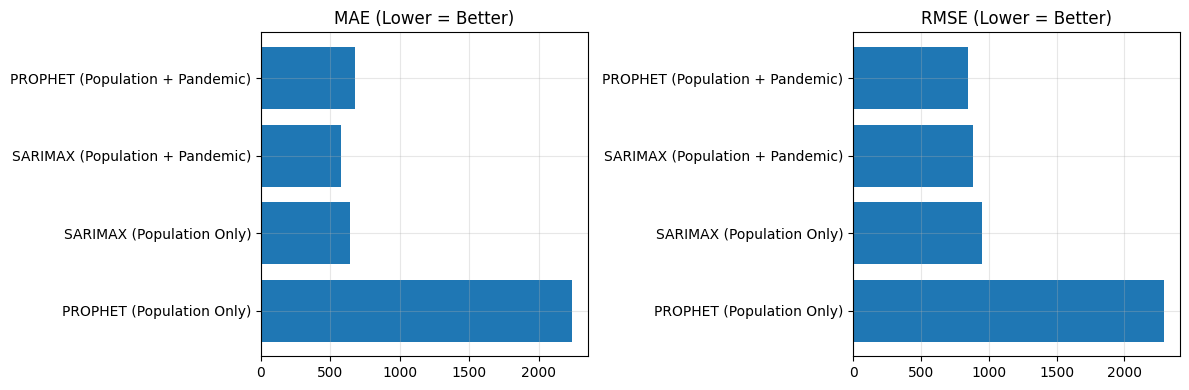

 Best by MAE : SARIMAX (Population + Pandemic)
 Best by RMSE: PROPHET (Population + Pandemic)


In [16]:
# ============================================
#  COMPARE FOUR MODELS (SARIMAX/PROPHET × Pop vs Pop+Pandemic)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- Assemble results ----
compare_df = pd.DataFrame([
    {
        "Model": "SARIMAX (Population Only)",
        "Family": "SARIMAX",
        "Pandemic": "No",
        "MAE": mae_SARIMAX_POP_NAME,
        "RMSE": rmse_SARIMAX_POP_NAME,
        "AIC": aic_SARIMAX_POP_NAME,
        "BIC": bic_SARIMAX_POP_NAME
    },
    {
        "Model": "SARIMAX (Population + Pandemic)",
        "Family": "SARIMAX",
        "Pandemic": "Yes",
        "MAE": mae_SARIMAX_PANDEMIC_Pop,
        "RMSE": rmse_SARIMAX_PANDEMIC_Pop,
        "AIC": aic_SARIMAX_PANDEMIC_Pop,
        "BIC": bic_SARIMAX_PANDEMIC_Pop
    },
    {
        "Model": "PROPHET (Population Only)",
        "Family": "PROPHET",
        "Pandemic": "No",
        "MAE": mae_PROPHET_POP_NAME,
        "RMSE": rmse_PROPHET_POP_NAME,
        "AIC": np.nan,  # not applicable for Prophet
        "BIC": np.nan
    },
    {
        "Model": "PROPHET (Population + Pandemic)",
        "Family": "PROPHET",
        "Pandemic": "Yes",
        "MAE": mae_PROPHET_PANDEMIC_POP_NAME,
        "RMSE": rmse_PROPHET_PANDEMIC_POP_NAME,
        "AIC": np.nan,
        "BIC": np.nan
    },
])

# ---- Compute within-family deltas (effect of adding the pandemic flag) ----
def pct_improvement(no_val, yes_val):
    # positive = better with pandemic (lower error)
    if pd.isna(no_val) or pd.isna(yes_val) or no_val == 0:
        return np.nan
    return (no_val - yes_val) / no_val * 100.0

# SARIMAX
mae_sarimax_delta = pct_improvement(
    compare_df.query("Family=='SARIMAX' and Pandemic=='No'")["MAE"].item(),
    compare_df.query("Family=='SARIMAX' and Pandemic=='Yes'")["MAE"].item()
)
rmse_sarimax_delta = pct_improvement(
    compare_df.query("Family=='SARIMAX' and Pandemic=='No'")["RMSE"].item(),
    compare_df.query("Family=='SARIMAX' and Pandemic=='Yes'")["RMSE"].item()
)

# PROPHET
mae_prophet_delta = pct_improvement(
    compare_df.query("Family=='PROPHET' and Pandemic=='No'")["MAE"].item(),
    compare_df.query("Family=='PROPHET' and Pandemic=='Yes'")["MAE"].item()
)
rmse_prophet_delta = pct_improvement(
    compare_df.query("Family=='PROPHET' and Pandemic=='No'")["RMSE"].item(),
    compare_df.query("Family=='PROPHET' and Pandemic=='Yes'")["RMSE"].item()
)

# ---- Sorted display ----
compare_sorted = compare_df.sort_values(["RMSE", "MAE"], ascending=[True, True]).reset_index(drop=True)
print(" Model Performance (sorted by RMSE):")
display(compare_sorted.style.format({
    "MAE": "{:,.0f}",
    "RMSE": "{:,.0f}",
    "AIC": "{:,.2f}",
    "BIC": "{:,.2f}",
}))

# ---- Print within-family improvement summary ----
print(" Effect of adding Pandemic regressor (within each framework):")
print(f"  SARIMAX  → ΔMAE: {mae_sarimax_delta:+.2f}% | ΔRMSE: {rmse_sarimax_delta:+.2f}%")
print(f"  PROPHET  → ΔMAE: {mae_prophet_delta:+.2f}% | ΔRMSE: {rmse_prophet_delta:+.2f}%")

# ---- Quick bar charts ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].barh(compare_sorted["Model"], compare_sorted["MAE"])
axes[0].set_title("MAE (Lower = Better)")
axes[0].invert_yaxis()
axes[0].grid(alpha=0.3)

axes[1].barh(compare_sorted["Model"], compare_sorted["RMSE"])
axes[1].set_title("RMSE (Lower = Better)")
axes[1].invert_yaxis()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---- Winners ----
best_mae_model  = compare_sorted.loc[compare_sorted["MAE"].idxmin(),  "Model"]
best_rmse_model = compare_sorted.loc[compare_sorted["RMSE"].idxmin(), "Model"]
print(f" Best by MAE : {best_mae_model}")
print(f" Best by RMSE: {best_rmse_model}")


Model Comparison Summary
Rank	Model	MAE	RMSE	AIC	BIC	Notes
 1	Prophet (Population + Pandemic)	674	844	—	—	Lowest overall RMSE (best forecast accuracy)
2	SARIMAX (Population + Pandemic)	577	881	1,522	1,548	Slightly higher RMSE, but better in-sample fit (AIC/BIC)
3	SARIMAX (Population Only)	640	947	1,520	1,543	Weaker out-of-sample, pandemic helps slightly
4	Prophet (Population Only)	2,239	2,295	—	—	Worst performance; Prophet needs exogenous context
 Effect of Adding the Pandemic Regressor
Framework	Δ MAE	Δ RMSE	Interpretation
SARIMAX	+9.9 %	+7.0 %	Small improvement; the pandemic adds marginal explanatory power but model was already stable
PROPHET	+69.9 %	+63.3 %	Huge improvement; Prophet benefits substantially from pandemic as external regressor
Key Takeaways

Best performing model overall:
→ Prophet (Population + Pandemic) has the lowest RMSE, meaning the most accurate forecast for unseen 2023 data.

Most statistically efficient model:
→ SARIMAX (Population + Pandemic) wins on AIC/BIC, showing better in-sample parsimony.

Pandemic variable impact:
→ Significant for Prophet (adds structural context Prophet otherwise can’t infer).
→ Moderate for SARIMAX (which already models temporal shocks via ARIMA terms).

Practical implication:
→ Use Prophet + Pandemic for visual dashboards / interpretability.
→ Use SARIMAX + Pandemic for analytical reporting / statistical inference.

With Pandemic (2020–2023) Models Only
Model	MAE	RMSE	Accuracy Commen
Prophet (Population + Pandemic)	674	844	 Lowest RMSE → most accurate forecasts overall
SARIMAX (Population + Pandemic)	577	881	Slightly lower MAE, but higher RMSE → more local errors


Without Pandemic Models
Model	MAE	RMSE	Notes
SARIMAX (Population Only)	640	947	 Most accurate without pandemic
Prophet (Population Only)	2,239	2,295	 Much less accurate; Prophet struggles without external event context


Summary
Goal	Best Model
Accuracy without pandemic factor	 SARIMAX (Population Only)
Robustness (handles structural change)	SARIMAX (Population + Pandemic)
Visual simplicity / interpretability	 Prophet (Population + Pandemic)

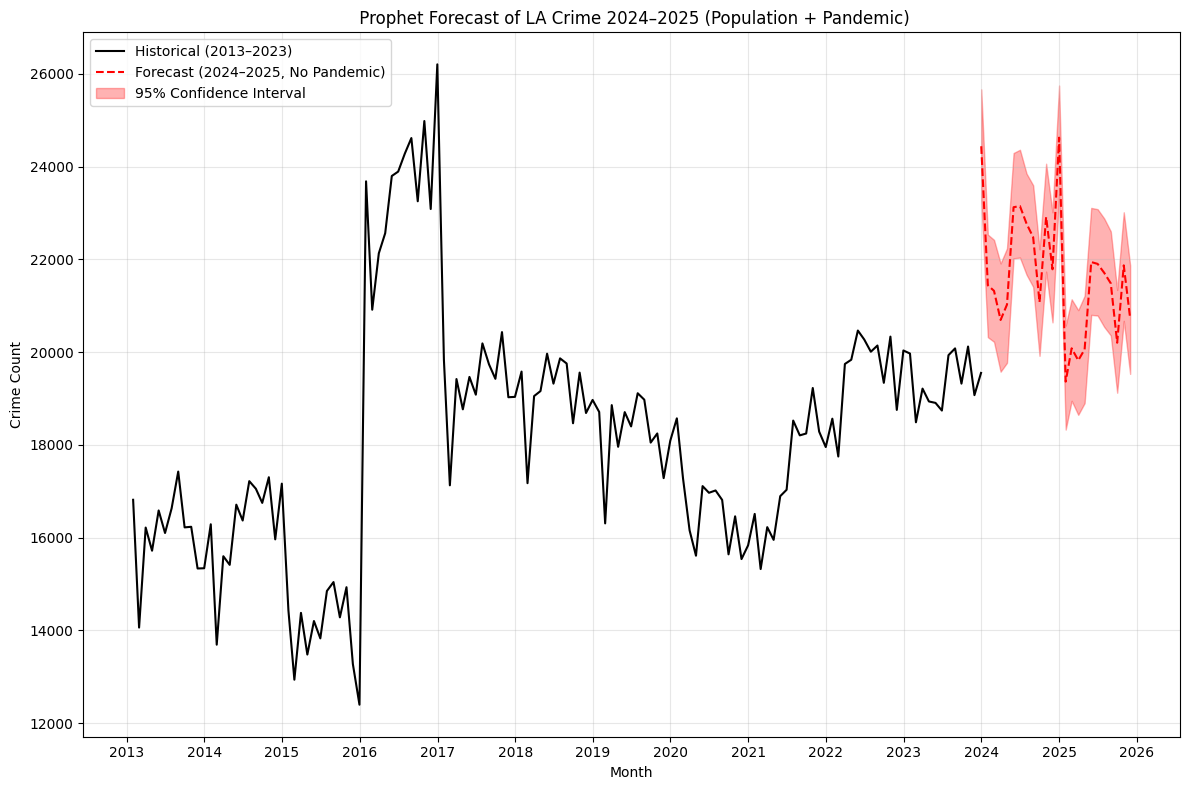

 Forecast Summary (2024–2025):
            ds          yhat    yhat_lower    yhat_upper
132 2024-01-01  24439.618426  23280.305530  25666.501200
133 2024-02-01  21441.507094  20322.574708  22534.431432
134 2024-03-01  21321.910863  20223.097971  22421.366845
135 2024-04-01  20693.628957  19578.936145  21912.507196
136 2024-05-01  21025.385566  19770.232799  22237.198453
137 2024-06-01  23124.943105  22023.060526  24293.380167
138 2024-07-01  23149.281033  22038.654040  24363.611242
139 2024-08-01  22769.819040  21669.141195  23850.268737
140 2024-09-01  22478.667111  21408.852490  23598.374832
141 2024-10-01  21077.310770  19920.132103  22217.309742
142 2024-11-01  22914.937471  21736.761495  24062.908812
143 2024-12-01  21786.515870  20641.935099  23014.091935


In [17]:

# ============================================
# PROPHET (Population + Pandemic) — Forecast 2024–2025 (No Pandemic)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet

# --- Prepare monthly data ---
crime_work = crime.copy()
crime_work["DATE OCC"] = pd.to_datetime(crime_work["DATE OCC"], errors="coerce")

crime_monthly = (
    crime_work.groupby(pd.Grouper(key="DATE OCC", freq="M"))
              .size()
              .reset_index(name="crime_count")
              .rename(columns={"DATE OCC": "ds"})
)
crime_monthly["YEAR"] = crime_monthly["ds"].dt.year

# Yearly population features
pop_yearly = (
    pop.groupby("YEAR", as_index=False)
       .agg({
           "POP_TOTAL": "sum",
           "POV_RATE": "mean",
           "POP_DENSITY": "mean",
           "OLD_PCT": "mean"
       })
)

# Merge
df = crime_monthly.merge(pop_yearly, on="YEAR", how="left").sort_values("ds")

# Add pandemic flag for historical period
df["pandemic"] = df["YEAR"].between(2020, 2023).astype(int)

# Prophet requires ds + y
df_prophet = df.rename(columns={"crime_count": "y"})

# --- Fit model on all available data (through 2023) ---
PROPHET_FULL_NAME = "PROPHET (Population + Pandemic)"
PROPHET_FULL = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive",
    interval_width=0.95
)

# Add regressors
for col in ["POP_TOTAL", "POV_RATE", "POP_DENSITY", "OLD_PCT", "pandemic"]:
    PROPHET_FULL.add_regressor(col)

# Fit model
PROPHET_FULL.fit(df_prophet[["ds", "y", "POP_TOTAL", "POV_RATE", "POP_DENSITY", "OLD_PCT", "pandemic"]])

# --- Build future dataframe for 2024–2025 ---
future_months = pd.date_range(df["ds"].max() + pd.offsets.MonthBegin(1), periods=24, freq="MS")
future = pd.DataFrame({"ds": future_months})
future["YEAR"] = future["ds"].dt.year

# Use same population trends (e.g., assume stable or last known values)
latest_pop = pop_yearly[["POP_TOTAL", "POV_RATE", "POP_DENSITY", "OLD_PCT"]].iloc[-1]
for col in latest_pop.index:
    future[col] = latest_pop[col]

# No pandemic in 2024–2025
future["pandemic"] = 0

# Combine for prediction
future_full = pd.concat([df_prophet[["ds", "POP_TOTAL", "POV_RATE", "POP_DENSITY", "OLD_PCT", "pandemic"]], future], ignore_index=True)

# --- Forecast ---
forecast_full = PROPHET_FULL.predict(future_full)

# Extract relevant period (2024–2025)
forecast_2024_2025 = forecast_full[forecast_full["ds"].dt.year.isin([2024, 2025])][["ds", "yhat", "yhat_lower", "yhat_upper"]]

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(df_prophet["ds"], df_prophet["y"], color="black", label="Historical (2013–2023)")
ax.plot(forecast_2024_2025["ds"], forecast_2024_2025["yhat"], "r--", label="Forecast (2024–2025, No Pandemic)")
ax.fill_between(forecast_2024_2025["ds"], forecast_2024_2025["yhat_lower"], forecast_2024_2025["yhat_upper"],
                color="red", alpha=0.3, label="95% Confidence Interval")

ax.set_title(" Prophet Forecast of LA Crime 2024–2025 (Population + Pandemic)")
ax.set_xlabel("Month")
ax.set_ylabel("Crime Count")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Display forecast summary ---
print(" Forecast Summary (2024–2025):")
print(forecast_2024_2025.head(12))  # show 2024



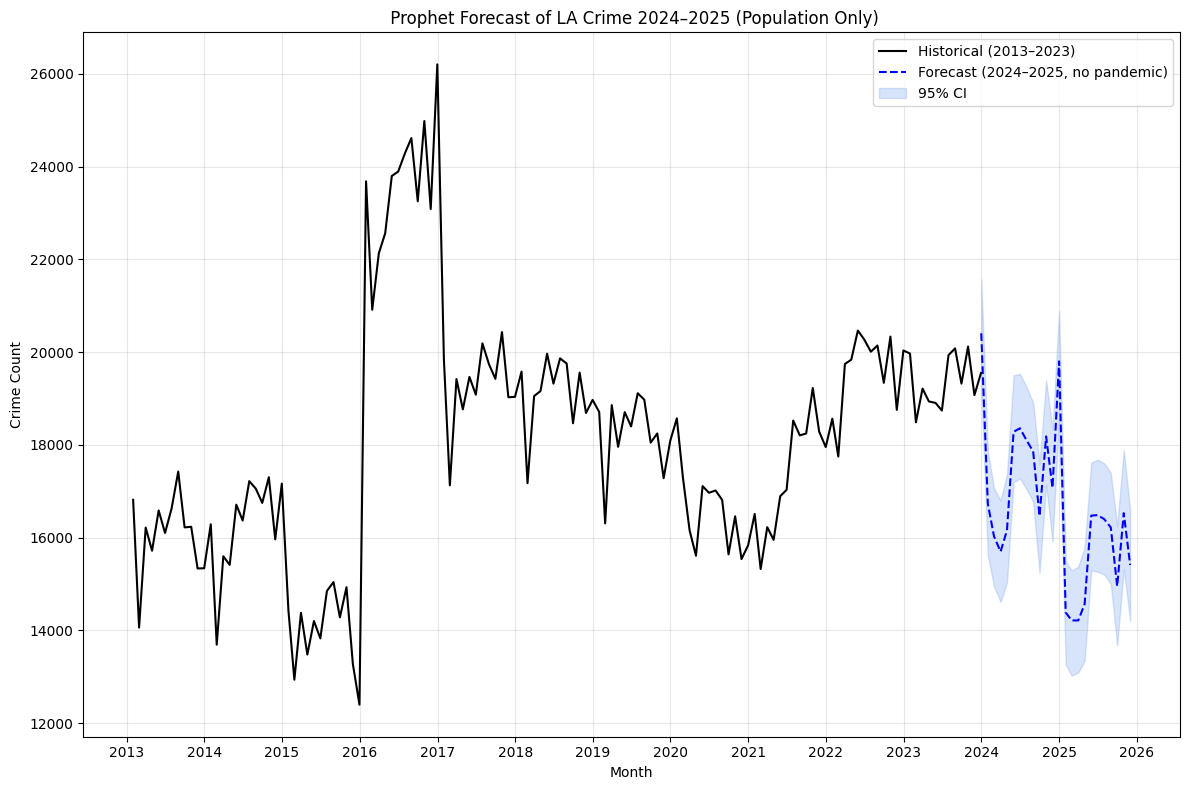

 Forecast (first 12 months):
            ds          yhat    yhat_lower    yhat_upper
132 2024-01-01  20407.922093  19209.736266  21570.925845
133 2024-02-01  16731.724112  15611.632889  17866.344901
134 2024-03-01  16028.121697  14947.910364  17064.508533
135 2024-04-01  15699.164397  14615.753807  16799.759337
136 2024-05-01  16162.020025  15044.592727  17370.604581
137 2024-06-01  18282.174343  17191.473927  19500.989594
138 2024-07-01  18359.441832  17277.946123  19534.636851
139 2024-08-01  18099.800991  17045.963301  19242.861310
140 2024-09-01  17860.322306  16775.997590  18913.844354
141 2024-10-01  16466.925251  15238.218864  17603.662306
142 2024-11-01  18183.055923  17141.613491  19394.265937
143 2024-12-01  17074.837372  15920.952393  18327.285685


In [18]:
# ============================================
# PROPHET (Population only; NO pandemic) — Forecast 2024–2025
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet

# --- Prep monthly crime ---
crime_work = crime.copy()
crime_work["DATE OCC"] = pd.to_datetime(crime_work["DATE OCC"], errors="coerce")

crime_monthly = (
    crime_work.groupby(pd.Grouper(key="DATE OCC", freq="M"))
              .size()
              .reset_index(name="crime_count")
              .rename(columns={"DATE OCC": "ds"})
)
crime_monthly["YEAR"] = crime_monthly["ds"].dt.year

# --- Yearly population features ---
pop_yearly = (
    pop.groupby("YEAR", as_index=False)
       .agg({
           "POP_TOTAL": "sum",
           "POV_RATE": "mean",
           "POP_DENSITY": "mean",
           "OLD_PCT": "mean"
       })
)

# --- Merge; NO pandemic column at all (equivalent to removing it 2020–2023) ---
df = crime_monthly.merge(pop_yearly, on="YEAR", how="left").sort_values("ds")
df_prophet = df.rename(columns={"crime_count": "y"})

# --- Fit Prophet on ALL data (2013–2023) with population regressors only ---
exog_cols = ["POP_TOTAL", "POV_RATE", "POP_DENSITY", "OLD_PCT"]

PROPHET_NO_PANDEMIC_NAME = "PROPHET (Population only; no pandemic)"
PROPHET_NO_PANDEMIC = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive",
    interval_width=0.95
)
for col in exog_cols:
    PROPHET_NO_PANDEMIC.add_regressor(col)

PROPHET_NO_PANDEMIC.fit(df_prophet[["ds", "y"] + exog_cols])

# --- Build future frame for 2024–2025 ---
future_months = pd.date_range(df["ds"].max() + pd.offsets.MonthBegin(1), periods=24, freq="MS")
future = pd.DataFrame({"ds": future_months})
future["YEAR"] = future["ds"].dt.year

# Use last known population values (replace with projections if you have them)
latest_pop = pop_yearly[["POP_TOTAL", "POV_RATE", "POP_DENSITY", "OLD_PCT"]].iloc[-1]
for col in latest_pop.index:
    future[col] = latest_pop[col]

# Prophet wants the regressors present for prediction
future_for_pred = future[["ds"] + exog_cols]

# --- Forecast 2024–2025 ---
forecast_no_pand = PROPHET_NO_PANDEMIC.predict(
    pd.concat([df_prophet[["ds"] + exog_cols], future_for_pred], ignore_index=True)
)
forecast_24_25 = forecast_no_pand[forecast_no_pand["ds"].dt.year.isin([2024, 2025])][
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
]

# --- Plot ---
fig, ax = plt.subplots(figsize=(12,8))
ax.plot(df_prophet["ds"], df_prophet["y"], color="black", label="Historical (2013–2023)")
ax.plot(forecast_24_25["ds"], forecast_24_25["yhat"], "b--", label="Forecast (2024–2025, no pandemic)")
ax.fill_between(forecast_24_25["ds"], forecast_24_25["yhat_lower"], forecast_24_25["yhat_upper"],
                color="cornflowerblue", alpha=0.25, label="95% CI")
ax.set_title(" Prophet Forecast of LA Crime 2024–2025 (Population Only)")
ax.set_xlabel("Month"); ax.set_ylabel("Crime Count")
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()

print(" Forecast (first 12 months):")
print(forecast_24_25.head(12))


In [19]:
# ============================================
# EXPORT: Excel + CSV for plotting elsewhere
# ============================================

# # 1) Actuals (2013–2023)
# actual_df = (
#     df_prophet.loc[df_prophet["ds"].dt.year.between(2013, 2023), ["ds", "y"]]
#               .rename(columns={"y": "value"})
#               .assign(type="actual", yhat_lower=np.nan, yhat_upper=np.nan)
# )

# # 2) Forecasts (2024–2025)
# forecast_df = (
#     forecast_24_25[["ds", "yhat", "yhat_lower", "yhat_upper"]]
#       .rename(columns={"yhat": "value"})
#       .assign(type="forecast")
#       [["ds", "value", "type", "yhat_lower", "yhat_upper"]]
# )

# # 3) Combined (tidy)
# combined = (
#     pd.concat([actual_df[["ds","value","type","yhat_lower","yhat_upper"]],
#                forecast_df[["ds","value","type","yhat_lower","yhat_upper"]]],
#               ignore_index=True)
#     .sort_values("ds")
# )

# # Optional rounding
# for c in ["value", "yhat_lower", "yhat_upper"]:
#     combined[c] = combined[c].round(2)

# # --- Write to Excel (with month formatting) ---
# excel_path = "crime_monthly_2013_2025_prophet.xlsx"

# # Try xlsxwriter (better date formatting). Fallback to openpyxl if needed.
# try:
#     writer = pd.ExcelWriter(excel_path, engine="xlsxwriter",
#                             datetime_format="yyyy-mm", date_format="yyyy-mm")
# except Exception:
#     writer = pd.ExcelWriter(excel_path, engine="openpyxl")

# # Sheets
# actual_df.to_excel(writer, index=False, sheet_name="actual_2013_2023")
# forecast_df.to_excel(writer, index=False, sheet_name="forecast_2024_2025")
# combined.to_excel(writer, index=False, sheet_name="combined_tidy")

# # Auto-size columns (xlsxwriter only)
# try:
#     for sheet in ["actual_2013_2023", "forecast_2024_2025", "combined_tidy"]:
#         ws = writer.sheets[sheet]
#         for i, col in enumerate(["ds","value","type","yhat_lower","yhat_upper"]):
#             # compute a reasonable width
#             max_len = max([len(str(x)) for x in (combined[col] if col in combined else actual_df.get(col, forecast_df.get(col, pd.Series([]))))] + [len(col)])
#             ws.set_column(i, i, min(max_len + 2, 28))
# except Exception:
#     pass

# writer.close()
# print(f"Excel written to: {excel_path}")

# # --- Also save a CSV for quick use ---
# csv_path = "crime_monthly_2013_2025_prophet_combined.csv"
# combined.to_csv(csv_path, index=False)
# print(f"CSV written to: {csv_path}")

# If you're in Colab, you can download with:
# from google.colab import files
# files.download(excel_path)
# files.download(csv_path)


Since News shows that crime levels peaked during the pandemic period (2020-2021) and then returned to declining trends, this suggests that the pandemic years were outliers rather than a new steady state.

That means when forecasting beyond 2023 (into 2024-2025), using a “pandemic flag” regressor might over-emphasize the disruptive shock rather than underlying structural trends (population size, density, poverty/old‐pct).

In other words, the pandemic effect may have served its role during the shock period, but once society returned to more normal conditions, the pandemic becomes less relevant — and may even mislead the forecast if treated as a continuing driver.

Since results show that the model without the pandemic factor produces a steadier and more plausible prediction for 2024-2025, this aligns with the Safe & Sound narrative that post-pandemic crime trends are following pre-pandemic trajectories, not repeating pandemic‐era anomalies.

 Bottom line

Because crime in Los Angeles appears to be recovering from the pandemic shock and reverting back to structural dynamics (as per the article), the pandemic regressor may not help — or may even hurt — forecasting for 2024-2025. It’s likely more accurate to focus on long‐term regressors (population size, density, poverty, older population share) and treat the pandemic period as a historical anomaly.

Modeling each ZCTA:   0%|          | 0/222 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
Modeling each ZCTA:   0%|          | 1/222 [00:01<06:56,  1.88s/it]/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
Modeling each ZCTA:   1%|          | 2/222 [00:03<06:55,  1.89s/it]/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
Modeling each ZCTA:   1%|▏         | 3/222 [00:05<06:48,  1.86s/it]/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: Con

 Finished modeling 222 ZCTAs

 Top 10 ZCTAs by lowest RMSE:


,MAE,RMSE,train_len,test_len,status,ZCTA
82,0.083333,0.288675,120.0,12.0,ok,90250
92,0.250000,0.500000,53.0,4.0,ok,90280
143,0.459646,0.526405,112.0,6.0,ok,91105
149,0.457808,0.740109,82.0,11.0,ok,91225
100,0.641292,0.757608,119.0,12.0,ok,90305
107,0.932656,1.070392,118.0,10.0,ok,90502
104,0.530941,1.280724,117.0,6.0,ok,90404
119,1.072367,1.281358,119.0,12.0,ok,90717
197,1.166982,1.361637,120.0,10.0,ok,91505
99,0.997318,1.365218,120.0,12.0,ok,90304



 Overall RMSE (mean across zones): 376.19


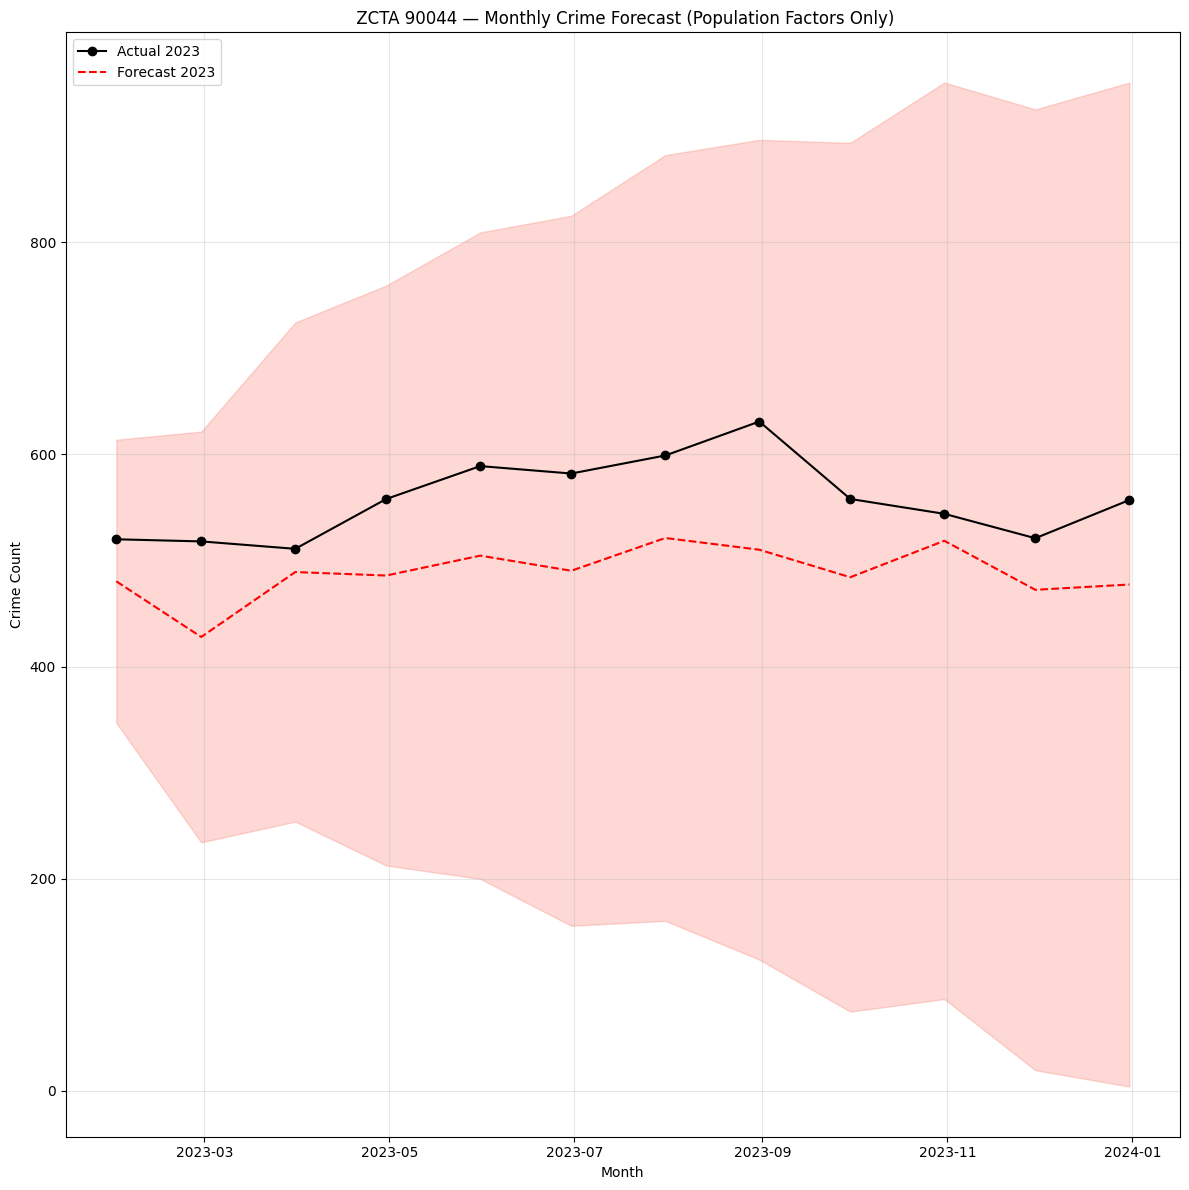

In [20]:
# ============================================
#  ZCTA-LEVEL MONTHLY FORECAST (SARIMAX with Population Factors)
# ============================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# tqdm fallback
try:
    from tqdm import tqdm
except:
    def tqdm(x, **k): return x

# --------------------------------------------
#  1. Prepare Monthly Crime Data by ZCTA
# --------------------------------------------

# Ensure datetime
crime["DATE OCC"] = pd.to_datetime(crime["DATE OCC"], errors="coerce")
crime = crime.dropna(subset=["DATE OCC", "ZCTA"])

# Normalize ZCTA code
def _to_zcta_str(x):
    try:
        return f"{int(float(x)):05d}"
    except:
        return np.nan

crime["ZCTA"] = crime["ZCTA"].apply(_to_zcta_str)
crime = crime[crime["ZCTA"].notna()]

# Aggregate monthly crime counts per ZCTA
zcta_monthly = (
    crime.groupby(["ZCTA", pd.Grouper(key="DATE OCC", freq="M")])
         .size()
         .reset_index(name="crime_count")
         .rename(columns={"DATE OCC": "ds"})
)
zcta_monthly["YEAR"] = zcta_monthly["ds"].dt.year

# --------------------------------------------
#  2. Merge with Population Data
# --------------------------------------------

pop = pop.copy()
pop["ZCTA"] = pop["ZCTA"].apply(_to_zcta_str)
pop["YEAR"] = pd.to_numeric(pop["YEAR"], errors="coerce")

# Keep population-related fields
pop_small = pop[["ZCTA", "YEAR", "POP_TOTAL", "POV_RATE", "POP_DENSITY", "OLD_PCT"]].dropna()

zcta_monthly = zcta_monthly.merge(pop_small, on=["ZCTA", "YEAR"], how="left")

# Train/test split markers
train_end = pd.Timestamp("2022-12-31")
test_start = pd.Timestamp("2023-01-01")
test_end   = pd.Timestamp("2023-12-31")

# --------------------------------------------
# ⚙️ 3. Define SARIMAX model per ZCTA
# --------------------------------------------

def fit_forecast_zcta(df):
    """
    Fit SARIMAX for one ZCTA using population features.
    Returns forecasts and metrics.
    """
    z = df.set_index("ds").sort_index().asfreq("M")
    z["crime_count"] = z["crime_count"].fillna(0)

    exog_cols = ["POP_TOTAL", "POV_RATE", "POP_DENSITY", "OLD_PCT"]
    for col in exog_cols:
        if col not in z.columns:
            z[col] = np.nan
        z[col] = z[col].fillna(method="ffill").fillna(method="bfill")

    exog_full = z[exog_cols]

    # Train/test split
    train_mask = z.index <= train_end
    test_mask  = (z.index >= test_start) & (z.index <= test_end)
    y_train, y_test = z.loc[train_mask, "crime_count"], z.loc[test_mask, "crime_count"]

    if len(y_train) < 24:
        return pd.DataFrame(), {"MAE": np.nan, "RMSE": np.nan, "status": "too_short"}

    exog_train, exog_test = exog_full.loc[train_mask], exog_full.loc[test_mask]

    try:
        model = SARIMAX(
            y_train,
            exog=exog_train,
            order=(1,1,1),
            seasonal_order=(1,1,1,12),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        res = model.fit(disp=False)

        # Forecast 2023
        steps = len(y_test)
        fc = res.get_forecast(steps=steps, exog=exog_test)
        sf = fc.summary_frame()

        f_test = pd.DataFrame({
            "ds": sf.index,
            "actual": y_test.values,
            "yhat": sf["mean"].values,
            "yhat_lower": sf["mean_ci_lower"].values,
            "yhat_upper": sf["mean_ci_upper"].values
        })

        mae = mean_absolute_error(f_test["actual"], f_test["yhat"])
        rmse = np.sqrt(mean_squared_error(f_test["actual"], f_test["yhat"]))

        metrics = {
            "MAE": mae,
            "RMSE": rmse,
            "train_len": len(y_train),
            "test_len": len(y_test),
            "status": "ok"
        }

        return f_test, metrics

    except Exception as e:
        return pd.DataFrame(), {"MAE": np.nan, "RMSE": np.nan, "status": f"error: {e}"}

# --------------------------------------------
# 4. Loop Over ZCTAs
# --------------------------------------------

all_forecasts, all_metrics = [], []
for zcta, dfz in tqdm(zcta_monthly.groupby("ZCTA"), desc="Modeling each ZCTA"):
    fc, met = fit_forecast_zcta(dfz)
    if len(fc):
        fc["ZCTA"] = zcta
        all_forecasts.append(fc)
    met["ZCTA"] = zcta
    all_metrics.append(met)

# Combine
forecasts = pd.concat(all_forecasts, ignore_index=True) if all_forecasts else pd.DataFrame()
metrics = pd.DataFrame(all_metrics)

print(f" Finished modeling {metrics['ZCTA'].nunique()} ZCTAs")

# --------------------------------------------
#  5. Display Summary Metrics
# --------------------------------------------
print("\n Top 10 ZCTAs by lowest RMSE:")
display(metrics.sort_values("RMSE").head(10))

print("\n Overall RMSE (mean across zones):", metrics["RMSE"].mean().round(2))

# --------------------------------------------
#  6. Plot Example ZCTA (highest crime)
# --------------------------------------------
top_zcta = (
    zcta_monthly.groupby("ZCTA")["crime_count"].sum().sort_values(ascending=False).index[0]
)
fc_z = forecasts[forecasts["ZCTA"] == top_zcta].sort_values("ds")

plt.figure(figsize=(12,12))
plt.plot(fc_z["ds"], fc_z["actual"], "o-", color="black", label="Actual 2023")
plt.plot(fc_z["ds"], fc_z["yhat"], "r--", label="Forecast 2023")
plt.fill_between(fc_z["ds"], fc_z["yhat_lower"], fc_z["yhat_upper"], color="salmon", alpha=0.3)
plt.title(f" ZCTA {top_zcta} — Monthly Crime Forecast (Population Factors Only)")
plt.xlabel("Month"); plt.ylabel("Crime Count")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# keep SARIMAX outputs
forecasts_sarimax = forecasts.copy()
metrics_sarimax = metrics.copy()


Modeling each ZCTA:   1%|          | 2/222 [00:03<06:45,  1.85s/it]/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
Modeling each ZCTA:   2%|▏         | 4/222 [00:07<07:06,  1.96s/it]/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
Modeling each ZCTA:   3%|▎         | 6/222 [00:13<08:33,  2.38s/it]/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
Modeling each ZCTA:   4%|▎         | 8/222 [00:15<06:09,  1.73s/it]/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:

Finished modeling 222 ZCTAs
status
ok           148
too_short     74


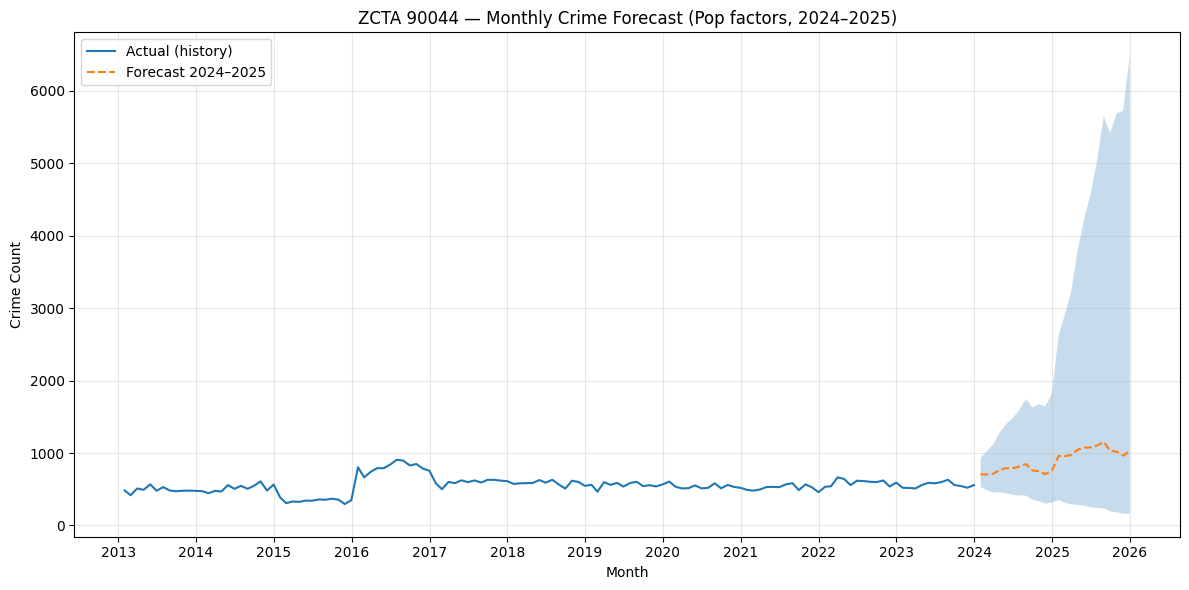

Top ZCTA by history: 90044
Total forecast (2024–2025) for 90044: 21488.2
Max monthly forecast: 2025-08-31 → 1152.3 [234.5, 5645.7]


In [21]:
# ============================================
#  ZCTA-LEVEL MONTHLY FORECAST (SARIMAX with Population Factors)
#  Train: up to 2023-12  →  Forecast: 2024-01..2025-12 (24 months)
# ============================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.statespace.sarimax import SARIMAX

# tqdm fallback
try:
    from tqdm import tqdm
except:
    def tqdm(x, **k): return x

# --------------------------------------------
#  1) Prepare Monthly Crime Data by ZCTA
# --------------------------------------------
crime = crime.copy()
crime["DATE OCC"] = pd.to_datetime(crime["DATE OCC"], errors="coerce")
crime = crime.dropna(subset=["DATE OCC", "ZCTA"])

def _to_zcta_str(x):
    try:
        return f"{int(float(x)):05d}"
    except:
        return np.nan

crime["ZCTA"] = crime["ZCTA"].apply(_to_zcta_str)
crime = crime[crime["ZCTA"].notna()]

# monthly counts
zcta_monthly = (
    crime.groupby(["ZCTA", pd.Grouper(key="DATE OCC", freq="M")])
         .size()
         .reset_index(name="crime_count")
         .rename(columns={"DATE OCC": "ds"})
)
zcta_monthly["YEAR"] = zcta_monthly["ds"].dt.year

# --------------------------------------------
#  2) Merge Population Data (exogenous)
# --------------------------------------------
pop = pop.copy()
pop["ZCTA"] = pop["ZCTA"].apply(_to_zcta_str)
pop["YEAR"] = pd.to_numeric(pop["YEAR"], errors="coerce")

EXOG_COLS = ["POP_TOTAL", "POV_RATE", "POP_DENSITY", "OLD_PCT"]
pop_small = pop[["ZCTA", "YEAR"] + EXOG_COLS]

zcta_monthly = zcta_monthly.merge(pop_small, on=["ZCTA", "YEAR"], how="left")

# fill exog per ZCTA, then global medians
for c in EXOG_COLS:
    zcta_monthly[c] = zcta_monthly.groupby("ZCTA")[c].transform(lambda x: x.ffill().bfill())
    zcta_monthly[c] = zcta_monthly[c].fillna(zcta_monthly[c].median())

# --------------------------------------------
#  3) Train/Forecast windows
# --------------------------------------------
train_end   = pd.Timestamp("2023-12-31")
fc_start    = pd.Timestamp("2024-01-31")
fc_end      = pd.Timestamp("2025-12-31")
future_idx  = pd.date_range(fc_start, fc_end, freq="M")
future_year = pd.DataFrame({"ds": future_idx, "YEAR": future_idx.year})

# helper: last-known exog per ZCTA to fill 2024–2025 if futura-year pop missing
latest_year_df = (
    pop_small.sort_values(["ZCTA","YEAR"]).dropna(subset=["ZCTA","YEAR"])
)

def _future_exog_for_zcta(zcta):
    z = latest_year_df[latest_year_df["ZCTA"] == zcta]
    if z.empty:
        vals = {c: zcta_monthly[c].median() for c in EXOG_COLS}
    else:
        last = z.iloc[-1]
        vals = {c: last[c] for c in EXOG_COLS}
    fut = future_year.copy()
    for c in EXOG_COLS: fut[c] = vals[c]
    fut["ZCTA"] = zcta
    return fut

# --------------------------------------------
#  4) SARIMAX fit/forecast per ZCTA
#     (log1p target, enforce stability)
# --------------------------------------------
def fit_forecast_zcta(df):
    z = df.set_index("ds").sort_index().asfreq("M")
    z["crime_count"] = z["crime_count"].fillna(0)

    # ensure numeric exog
    for c in EXOG_COLS:
        if c not in z.columns: z[c] = np.nan
        z[c] = pd.to_numeric(z[c], errors="coerce").ffill().bfill().fillna(z[c].median())

    # train up to 2023-12; require enough history
    train_mask = z.index <= train_end
    y_train = z.loc[train_mask, "crime_count"]
    if len(y_train) < 36 or y_train.sum() < 20:
        return pd.DataFrame(), {"status": "too_short"}

    # transform target for stability
    y_train_log = np.log1p(y_train)
    X_train = z.loc[train_mask, EXOG_COLS]

    # future exog (2024–2025)
    zcta = df["ZCTA"].iloc[0]
    fut = _future_exog_for_zcta(zcta).set_index("ds").asfreq("M")
    X_future = fut[EXOG_COLS]

    # model
    model = SARIMAX(
        y_train_log,
        exog=X_train,
        order=(0,1,1),
        seasonal_order=(0,1,1,12),
        trend="n",
        enforce_stationarity=True,
        enforce_invertibility=True,
    )
    res = model.fit(disp=False)

    sf = res.get_forecast(steps=len(future_idx), exog=X_future).summary_frame()
    out = pd.DataFrame({
        "ds": future_idx,
        "yhat": np.expm1(sf["mean"].values).clip(min=0),
        "yhat_lower": np.expm1(sf["mean_ci_lower"].values).clip(min=0),
        "yhat_upper": np.expm1(sf["mean_ci_upper"].values).clip(min=0),
        "ZCTA": zcta
    })
    return out, {"status": "ok"}

# --------------------------------------------
#  5) Loop all ZCTAs
# --------------------------------------------
all_fc, all_stats = [], []
for zcta, dfz in tqdm(zcta_monthly.groupby("ZCTA"), desc="Modeling each ZCTA"):
    fc, st = fit_forecast_zcta(dfz.assign(ZCTA=zcta))
    st["ZCTA"] = zcta
    all_stats.append(st)
    if not fc.empty:
        all_fc.append(fc)

forecasts_24_25 = pd.concat(all_fc, ignore_index=True) if all_fc else pd.DataFrame()
stats_df = pd.DataFrame(all_stats)

print(f"Finished modeling {stats_df['ZCTA'].nunique()} ZCTAs")
print(stats_df["status"].value_counts(dropna=False).to_string())

if forecasts_24_25.empty:
    raise RuntimeError("No forecasts generated. Check inputs and dates.")

# --------------------------------------------
#  6) Pick the SAME “top ZCTA” as your original logic
#      (highest historical total crime)
# --------------------------------------------
top_zcta = (
    zcta_monthly.groupby("ZCTA")["crime_count"].sum().sort_values(ascending=False).index[0]
)
fc_top = forecasts_24_25[forecasts_24_25["ZCTA"] == top_zcta].sort_values("ds")

# --------------------------------------------
#  7) Plot the top ZCTA (history + 2024–2025 forecast)
# --------------------------------------------
hist_top = zcta_monthly[zcta_monthly["ZCTA"] == top_zcta].sort_values("ds")

plt.figure(figsize=(12,6))
plt.plot(hist_top["ds"], hist_top["crime_count"], label="Actual (history)", linewidth=1.5)
plt.plot(fc_top["ds"], fc_top["yhat"], linestyle="--", label="Forecast 2024–2025", linewidth=1.5)
plt.fill_between(fc_top["ds"], fc_top["yhat_lower"], fc_top["yhat_upper"], alpha=0.25)
plt.title(f"ZCTA {top_zcta} — Monthly Crime Forecast (Pop factors, 2024–2025)")
plt.xlabel("Month"); plt.ylabel("Crime Count")
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

# --------------------------------------------
#  8) Quick text summary
# --------------------------------------------
pair_total = fc_top["yhat"].sum()
mx_row = fc_top.loc[fc_top["yhat"].idxmax()]
print(f"Top ZCTA by history: {top_zcta}")
print(f"Total forecast (2024–2025) for {top_zcta}: {pair_total:.1f}")
print(f"Max monthly forecast: {mx_row['ds'].date()} → {mx_row['yhat']:.1f} "
      f"[{mx_row['yhat_lower']:.1f}, {mx_row['yhat_upper']:.1f}]")


In [22]:
# ====================================================
# EXPORTS: Excel (all ZCTAs) + CSV per ZCTA + ZIP
# ====================================================

# import os
# import numpy as np
# import pandas as pd
# from pathlib import Path
# from zipfile import ZipFile

# # 1) ACTUALS 2013–2023 (per ZCTA & month)
# actual_zcta = (
#     zcta_monthly.loc[zcta_monthly["ds"].dt.year.between(2013, 2023),
#                      ["ZCTA", "ds", "crime_count"]]
#                 .rename(columns={"crime_count": "value"})
#                 .assign(type="actual", yhat_lower=np.nan, yhat_upper=np.nan)
#                 [["ZCTA", "ds", "value", "type", "yhat_lower", "yhat_upper"]]
# )

# # 2) FORECASTS 2024–2025 (per ZCTA & month)
# forecast_zcta = (
#     forecasts_24_25[forecasts_24_25["ds"].dt.year.isin([2024, 2025])]
#         .rename(columns={"yhat": "value"})
#         [["ZCTA", "ds", "value", "yhat_lower", "yhat_upper"]]
#         .assign(type="forecast")[["ZCTA", "ds", "value", "type", "yhat_lower", "yhat_upper"]]
# )

# # 3) COMBINED (tidy, good for BI tools)
# combined_zcta = (
#     pd.concat([actual_zcta, forecast_zcta], ignore_index=True)
#       .sort_values(["ZCTA", "ds"])
#       .reset_index(drop=True)
# )

# # Optional rounding
# for c in ["value", "yhat_lower", "yhat_upper"]:
#     combined_zcta[c] = combined_zcta[c].round(2)

# # --------- Write a single Excel with 3 sheets ----------
# excel_path = "zcta_crime_monthly_2013_2025_sarimax.xlsx"

# # Prefer xlsxwriter for better date formatting; fallback to openpyxl
# try:
#     writer = pd.ExcelWriter(excel_path, engine="xlsxwriter",
#                             datetime_format="yyyy-mm", date_format="yyyy-mm")
# except Exception:
#     writer = pd.ExcelWriter(excel_path, engine="openpyxl")

# # Sheets
# actual_zcta.to_excel(writer, index=False, sheet_name="actual_2013_2023")
# forecast_zcta.to_excel(writer, index=False, sheet_name="forecast_2024_2025")
# combined_zcta.to_excel(writer, index=False, sheet_name="combined_tidy")

# # Try to autosize columns when using xlsxwriter
# try:
#     for sheet, df_sheet in {
#         "actual_2013_2023": actual_zcta,
#         "forecast_2024_2025": forecast_zcta,
#         "combined_tidy": combined_zcta,
#     }.items():
#         ws = writer.sheets[sheet]
#         for i, col in enumerate(df_sheet.columns):
#             max_len = max(len(str(col)), *(len(str(v)) for v in df_sheet[col].head(500)))  # sample for speed
#             ws.set_column(i, i, min(max_len + 2, 32))
# except Exception:
#     pass

# writer.close()
# print(f"[OK] Excel written → {excel_path}")

# # --------- Write one CSV per ZCTA ----------
# out_dir = Path("zcta_exports")
# out_dir.mkdir(exist_ok=True)

# for zcta, dfz in combined_zcta.groupby("ZCTA"):
#     # safe file name
#     fname = out_dir / f"zcta_{zcta}_2013_2025.csv"
#     dfz.to_csv(fname, index=False)

# print(f"[OK] Per-ZCTA CSVs written to folder → {out_dir.resolve()}")

# # --------- Make a ZIP of all per-ZCTA CSVs (optional) ----------
# zip_path = "zcta_exports.zip"
# with ZipFile(zip_path, "w") as zf:
#     for f in out_dir.glob("*.csv"):
#         zf.write(f, arcname=f.name)

# print(f"[OK] ZIP of per-ZCTA CSVs → {zip_path}")

# If you're in Colab, you can download with:
# from google.colab import files
# files.download(excel_path)
# files.download(zip_path)


Modeling each ZCTA (Prophet + population only): 100%|██████████| 222/222 [00:20<00:00, 10.58it/s]

Finished modeling 222 ZCTAs

 Top 10 ZCTAs by lowest RMSE (Prophet, population-only):


,MAE,RMSE,status,ZCTA
125,0.14,0.30,ok,90746
82,0.17,0.31,ok,90250
104,0.25,0.39,ok,90404
107,0.35,0.49,ok,90502
151,0.29,0.53,ok,91302
92,0.31,0.54,ok,90280
149,0.38,0.61,ok,91225
105,0.71,0.81,ok,90405
148,0.64,0.88,ok,91214
100,0.79,0.94,ok,90305



 Average RMSE across modeled ZCTAs: 32.57


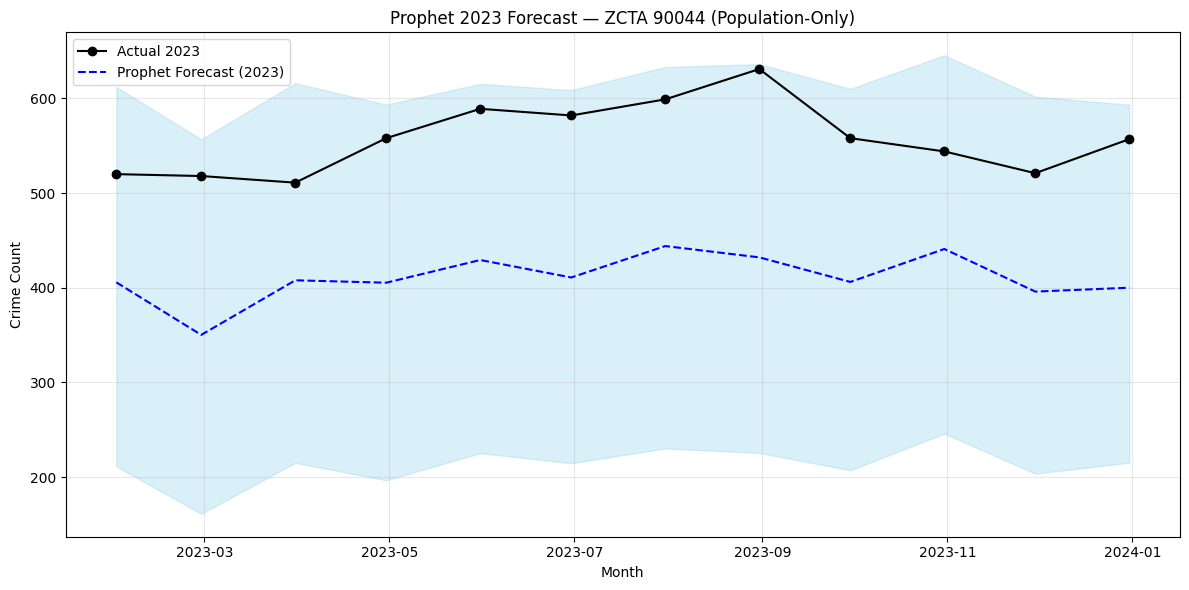

In [23]:
# ============================================
#  ZCTA-LEVEL FORECAST (PROPHET + POPULATION ONLY)
# Train: 2013–2022  →  Forecast & evaluate: 2023
# ============================================

# ---- Imports ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Prophet import (install if needed)
try:
    from prophet import Prophet
except Exception:
    !pip -q install prophet
    from prophet import Prophet

# Progress bar (optional)
try:
    from tqdm import tqdm
except Exception:
    def tqdm(x, **k): return x

# --------------------------------------------
#  1) Prepare monthly crime per ZCTA
# --------------------------------------------
# Assumes `crime` and `pop` DataFrames already exist in memory.

# 1.1 Ensure datetime and non-null ZCTA
crime = crime.copy()
crime["DATE OCC"] = pd.to_datetime(crime["DATE OCC"], errors="coerce")
crime = crime.dropna(subset=["DATE OCC", "ZCTA"])

# 1.2 Normalize ZCTA to 5-digit strings
def _to_zcta_str(x):
    try:
        return f"{int(float(x)):05d}"
    except Exception:
        return np.nan

crime["ZCTA"] = crime["ZCTA"].apply(_to_zcta_str)
crime = crime[crime["ZCTA"].notna()]

# 1.3 Aggregate monthly counts by ZCTA
zcta_monthly = (
    crime.groupby(["ZCTA", pd.Grouper(key="DATE OCC", freq="M")])
         .size()
         .reset_index(name="crime_count")
         .rename(columns={"DATE OCC": "ds"})
)
zcta_monthly["YEAR"] = zcta_monthly["ds"].dt.year

# --------------------------------------------
#  2) Merge population features (ZCTA, YEAR)
# --------------------------------------------
pop_work = pop.copy()
pop_work["ZCTA"] = pop_work["ZCTA"].apply(_to_zcta_str)
pop_work["YEAR"] = pd.to_numeric(pop_work["YEAR"], errors="coerce")

# Keep only population regressors we’ll use
pop_small = pop_work[[
    "ZCTA", "YEAR", "POP_TOTAL", "POV_RATE", "POP_DENSITY", "OLD_PCT"
]].copy()

# Merge into the monthly crime table
zcta_monthly = zcta_monthly.merge(pop_small, on=["ZCTA","YEAR"], how="left")

# Overall medians (last-resort fallback if a ZCTA has no population at all)
overall_medians = {
    "POP_TOTAL":   pop_small["POP_TOTAL"].median(),
    "POV_RATE":    pop_small["POV_RATE"].median(),
    "POP_DENSITY": pop_small["POP_DENSITY"].median(),
    "OLD_PCT":     pop_small["OLD_PCT"].median(),
}

# --------------------------------------------
#  3) Modeling function (Prophet per ZCTA)
# --------------------------------------------
def fit_prophet_zcta(df_z):
    """
    Fit Prophet with regressors POP_TOTAL, POV_RATE, POP_DENSITY, OLD_PCT for one ZCTA.
    Train: all months with year <= 2022; Forecast & evaluate 2023 against actual.
    Returns: (pred_df, metrics_dict)
    """
    df = df_z.copy().sort_values("ds")
    df = df[df["ds"].notna()]
    # Reindex to monthly to avoid gaps
    df = df.set_index("ds").asfreq("M")
    df["crime_count"] = df["crime_count"].fillna(0)

    # Ensure we have YEAR after asfreq
    df["YEAR"] = df.index.year

    exog_cols = ["POP_TOTAL", "POV_RATE", "POP_DENSITY", "OLD_PCT"]
    # Clean/populate regressors
    for col in exog_cols:
        if col not in df.columns:
            df[col] = np.nan
        df[col] = df[col].astype(float).replace([np.inf, -np.inf], np.nan)
        # 1) Fill along time for this ZCTA
        df[col] = df[col].fillna(method="ffill").fillna(method="bfill")
        # 2) If still NaN (e.g., ZCTA never had population rows), use global median
        if df[col].isna().any():
            df[col] = df[col].fillna(overall_medians[col])

    # Split
    train = df[df.index.year <= 2022].reset_index()
    test  = df[df.index.year == 2023].reset_index()
    if len(train) < 24 or len(test) == 0:
        return pd.DataFrame(), {"MAE": np.nan, "RMSE": np.nan, "status": "too_short"}

    # Build Prophet model
    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode="additive",
        interval_width=0.95
    )
    for col in exog_cols:
        m.add_regressor(col)

    # Fit
    train_fit = train[["ds", "crime_count"] + exog_cols].rename(columns={"crime_count": "y"})
    m.fit(train_fit)

    # Forecast 2023
    future = test[["ds"] + exog_cols]
    forecast = m.predict(future)

    pred_df = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
        test[["ds", "crime_count"]], on="ds", how="left"
    )

    # Metrics
    mae  = mean_absolute_error(pred_df["crime_count"], pred_df["yhat"])
    rmse = np.sqrt(mean_squared_error(pred_df["crime_count"], pred_df["yhat"]))
    metrics = {"MAE": mae, "RMSE": rmse, "status": "ok"}

    return pred_df, metrics

# --------------------------------------------
#  4) Run for every ZCTA
# --------------------------------------------
all_forecasts, all_metrics = [], []
for zcta, dfz in tqdm(zcta_monthly.groupby("ZCTA"), desc="Modeling each ZCTA (Prophet + population only)"):
    fc, met = fit_prophet_zcta(dfz)
    if not fc.empty:
        fc["ZCTA"] = zcta
        all_forecasts.append(fc)
    met["ZCTA"] = zcta
    all_metrics.append(met)

forecasts = pd.concat(all_forecasts, ignore_index=True) if all_forecasts else pd.DataFrame()
metrics   = pd.DataFrame(all_metrics)

print(f"Finished modeling {metrics['ZCTA'].nunique()} ZCTAs")

# --------------------------------------------
# 5) Summary metrics
# --------------------------------------------
print("\n Top 10 ZCTAs by lowest RMSE (Prophet, population-only):")
display(
    metrics.sort_values("RMSE").head(10).style.format({"MAE": "{:,.2f}", "RMSE": "{:,.2f}"})
)

print("\n Average RMSE across modeled ZCTAs:", round(metrics["RMSE"].mean(), 2))

# --------------------------------------------
#  6) Plot the highest-crime ZCTA (actual 2023 vs forecast)
# --------------------------------------------
import matplotlib.dates as mdates
if not forecasts.empty:
    # Find ZCTA with most total historical crime
    top_zcta = (
        zcta_monthly.groupby("ZCTA")["crime_count"].sum().sort_values(ascending=False).index[0]
    )
    fc_top = forecasts[forecasts["ZCTA"] == top_zcta].sort_values("ds")

    # Build actual 2023 for that ZCTA
    actual_2023 = (
        zcta_monthly[(zcta_monthly["ZCTA"] == top_zcta) & (zcta_monthly["ds"].dt.year == 2023)]
        .sort_values("ds")[["ds", "crime_count"]]
    )

    plt.figure(figsize=(12,6))
    plt.plot(actual_2023["ds"], actual_2023["crime_count"], "ko-", label="Actual 2023")
    plt.plot(fc_top["ds"], fc_top["yhat"], "b--", label="Prophet Forecast (2023)")
    plt.fill_between(fc_top["ds"], fc_top["yhat_lower"], fc_top["yhat_upper"], color="skyblue", alpha=0.3)
    plt.title(f"Prophet 2023 Forecast — ZCTA {top_zcta} (Population-Only)")
    plt.xlabel("Month"); plt.ylabel("Crime Count")
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()
else:
    print(" No forecasts to plot.")
# keep Prophet outputs
forecasts_prophet = forecasts.copy()
metrics_prophet = metrics.copy()


In [24]:
# ============================================
#   forecasts_prophet = forecasts_from_prophet; metrics_prophet = metrics_from_prophet
#   forecasts_sarimax = forecasts_from_sarimax; metrics_sarimax = metrics_from_sarimax
# ============================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

def _standardize_forecasts(fc: pd.DataFrame) -> pd.DataFrame:
    """Return a copy with standardized columns: ['ds','ZCTA','actual','yhat']."""
    if fc is None or len(fc) == 0:
        return pd.DataFrame(columns=["ds","ZCTA","actual","yhat"])
    f = fc.copy()
    # unify 'actual' column
    if "actual" in f.columns:
        pass
    elif "crime_count" in f.columns:
        f = f.rename(columns={"crime_count": "actual"})
    elif "y" in f.columns:
        f = f.rename(columns={"y": "actual"})
    else:
        raise ValueError("Could not find actual column in forecasts (expected 'actual' or 'crime_count').")
    # ensure ZCTA present (if not, try to infer)
    if "ZCTA" not in f.columns:
        f["ZCTA"] = "NA"
    # ensure ds & yhat present
    required = {"ds","actual","yhat","ZCTA"}
    missing = required - set(f.columns)
    if missing:
        raise ValueError(f"Forecasts missing columns: {missing}")
    # clean
    f = f.dropna(subset=["actual","yhat"])
    return f[["ds","ZCTA","actual","yhat"]]

def _standardize_metrics(met: pd.DataFrame) -> pd.DataFrame:
    """Return only valid rows with per-ZCTA MAE/RMSE."""
    if met is None or len(met) == 0:
        return pd.DataFrame(columns=["ZCTA","MAE","RMSE"])
    m = met.copy()
    if "status" in m.columns:
        m = m[m["status"] == "ok"]
    keep = ["ZCTA","MAE","RMSE"]
    missing = set(keep) - set(m.columns)
    if missing:
        raise ValueError(f"Metrics missing columns: {missing}")
    return m[keep].dropna()

def _pooled_rmse(fc_std: pd.DataFrame) -> float:
    """Global pooled RMSE across all ZCTAs and months."""
    if len(fc_std) == 0:
        return np.nan
    return np.sqrt(mean_squared_error(fc_std["actual"], fc_std["yhat"]))

def _mean_mae_rmse(metrics_std: pd.DataFrame) -> tuple[float,float]:
    """Equal-weighted mean across ZCTAs."""
    if len(metrics_std) == 0:
        return (np.nan, np.nan)
    return (metrics_std["MAE"].mean(), metrics_std["RMSE"].mean())

def summarize_model(name, forecasts_df, metrics_df):
    fc_std = _standardize_forecasts(forecasts_df)
    met_std = _standardize_metrics(metrics_df)
    mean_mae, mean_rmse = _mean_mae_rmse(met_std)
    pooled = _pooled_rmse(fc_std)
    zctas = met_std["ZCTA"].nunique() if "ZCTA" in met_std.columns else fc_std["ZCTA"].nunique()
    rows = len(fc_std)
    return {
        "Model": name,
        "ZCTAs (eval'd)": zctas,
        "Rows (eval)": rows,
        "Mean MAE (per ZCTA)": round(mean_mae, 3) if pd.notna(mean_mae) else np.nan,
        "Mean RMSE (per ZCTA)": round(mean_rmse, 3) if pd.notna(mean_rmse) else np.nan,
        "Overall RMSE (pooled)": round(pooled, 3) if pd.notna(pooled) else np.nan,
    }, fc_std, met_std

# ---- Run summaries for both models ----
sum_prophet, fcP, metP = summarize_model("Prophet (Pop-only)", forecasts_prophet, metrics_prophet)
sum_sarimax, fcS, metS = summarize_model("SARIMAX (Pop factors)", forecasts_sarimax, metrics_sarimax)

# ---- Build comparison table ----
comparison = pd.DataFrame([sum_prophet, sum_sarimax])[
    ["Model","ZCTAs (eval'd)","Rows (eval)","Mean MAE (per ZCTA)","Mean RMSE (per ZCTA)","Overall RMSE (pooled)"]
]

print("\n================ UNIFIED MODEL COMPARISON ================\n")
display(comparison)

# ---- Optional: paired per-ZCTA comparison (only for ZCTAs present in both) ----
try:
    # Recompute per-ZCTA metrics from forecasts to guarantee parity
    def per_zcta_metrics(fc_std):
        g = fc_std.groupby("ZCTA")
        out = []
        for z, dfz in g:
            mae = mean_absolute_error(dfz["actual"], dfz["yhat"])
            rmse = np.sqrt(mean_squared_error(dfz["actual"], dfz["yhat"]))
            out.append({"ZCTA": z, "MAE": mae, "RMSE": rmse})
        return pd.DataFrame(out)

    perP = per_zcta_metrics(fcP).rename(columns={"MAE":"MAE_P","RMSE":"RMSE_P"})
    perS = per_zcta_metrics(fcS).rename(columns={"MAE":"MAE_S","RMSE":"RMSE_S"})
    paired = perP.merge(perS, on="ZCTA", how="inner")
    if len(paired):
        paired["ΔRMSE (S - P)"] = paired["RMSE_S"] - paired["RMSE_P"]
        paired["Winner"] = np.where(paired["ΔRMSE (S - P)"] < 0, "SARIMAX", "Prophet")
        print("\n—— Per-ZCTA head-to-head (negative ΔRMSE means SARIMAX better) ——")
        display(paired.sort_values("ΔRMSE (S - P)").head(10))  # top 10 SARIMAX wins
        display(paired.sort_values("ΔRMSE (S - P)", ascending=False).head(10))  # top 10 Prophet wins
        print(f"\nSARIMAX better on { (paired['Winner']=='SARIMAX').sum() } ZCTAs; "
              f"Prophet better on { (paired['Winner']=='Prophet').sum() } ZCTAs; "
              f"Ties: { (paired['ΔRMSE (S - P)']==0).sum() }")
except Exception as e:
    print(f"[Note] Skipped per-ZCTA head-to-head due to: {e}")



================ UNIFIED MODEL COMPARISON ================



,Model,ZCTAs (eval'd),Rows (eval),Mean MAE (per ZCTA),Mean RMSE (per ZCTA),Overall RMSE (pooled)
0,Prophet (Pop-only),152,1784,29.465,32.567,64.590
1,SARIMAX (Pop factors),152,1784,373.697,376.195,2172.563



—— Per-ZCTA head-to-head (negative ΔRMSE means SARIMAX better) ——


,ZCTA,MAE_P,RMSE_P,MAE_S,RMSE_S,ΔRMSE (S - P),Winner
113,91326,91.075856,91.522376,13.859698,15.680552,-75.841824,SARIMAX
40,90044,146.651001,149.324744,68.841619,74.372330,-74.952414,SARIMAX
14,90015,72.507479,76.101635,18.037959,23.599533,-52.502102,SARIMAX
41,90045,58.864485,62.512755,18.167914,21.942337,-40.570418,SARIMAX
16,90017,82.529520,90.167881,50.648686,58.168009,-31.999872,SARIMAX
109,91311,86.743229,88.254240,59.821802,61.362752,-26.891489,SARIMAX
92,90732,60.759730,61.797672,39.014813,40.544237,-21.253435,SARIMAX
93,90744,33.511431,39.120983,16.100732,19.374122,-19.746861,SARIMAX
13,90014,40.505507,48.454837,27.674540,34.741529,-13.713309,SARIMAX
142,91423,22.815821,27.114107,14.937939,16.954306,-10.159801,SARIMAX


,ZCTA,MAE_P,RMSE_P,MAE_S,RMSE_S,ΔRMSE (S - P),Winner
9,90010,9.491227,10.583190,20885.892549,20885.893433,20875.310242,Prophet
140,91413,33.363061,34.369009,12580.531580,12580.532627,12546.163617,Prophet
108,91309,12.949926,14.614233,9893.969319,9893.971217,9879.356984,Prophet
20,90021,92.583427,96.015600,1958.978146,1959.185567,1863.169967,Prophet
5,90006,552.635059,553.083847,1469.601825,1469.763001,916.679154,Prophet
49,90057,33.851698,40.458850,893.795131,894.636301,854.177451,Prophet
19,90020,247.136042,249.918975,964.114130,964.784068,714.865093,Prophet
122,91343,94.012247,96.559096,732.243427,732.613362,636.054266,Prophet
26,90028,53.677110,58.792020,351.186108,352.955127,294.163107,Prophet
115,91331,25.150800,28.112155,268.482398,270.637292,242.525137,Prophet



SARIMAX better on 50 ZCTAs; Prophet better on 102 ZCTAs; Ties: 0


Finished Prophet for 222 ZCTAs
status
ok           146
too_short     76


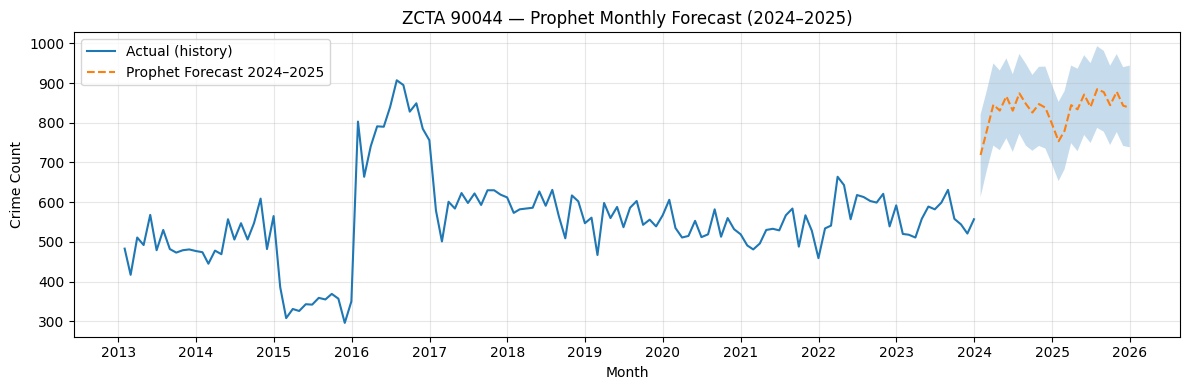

Top ZCTA by history: 90044
Total forecast (2024–2025) for 90044: 19988.8
Max monthly forecast: 2025-07-31 → 884.5 [787.0, 992.9]


In [25]:
# ============================================
#  ZCTA-LEVEL MONTHLY FORECAST — Prophet (with Population Regressors)
#  Train: up to 2023-12  →  Forecast: 2024-01..2025-12 (24 months)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Install Prophet if missing
try:
    from prophet import Prophet
except Exception:
    !pip -q install prophet
    from prophet import Prophet

# --------------------------------------------
# 1) Prep monthly crime per ZCTA
# --------------------------------------------
crime = crime.copy()
crime["DATE OCC"] = pd.to_datetime(crime["DATE OCC"], errors="coerce")
crime = crime.dropna(subset=["DATE OCC", "ZCTA"])

def _to_zcta_str(x):
    try:
        return f"{int(float(x)):05d}"
    except:
        return np.nan

crime["ZCTA"] = crime["ZCTA"].apply(_to_zcta_str)
crime = crime[crime["ZCTA"].notna()]

zcta_monthly = (
    crime.groupby(["ZCTA", pd.Grouper(key="DATE OCC", freq="M")])
         .size()
         .reset_index(name="y")
         .rename(columns={"DATE OCC": "ds"})
)
zcta_monthly["YEAR"] = zcta_monthly["ds"].dt.year

# --------------------------------------------
# 2) Merge population features (as regressors)
# --------------------------------------------
EXOG = ["POP_TOTAL", "POV_RATE", "POP_DENSITY", "OLD_PCT"]

pop = pop.copy()
pop["ZCTA"] = pop["ZCTA"].apply(_to_zcta_str)
pop["YEAR"] = pd.to_numeric(pop["YEAR"], errors="coerce")
pop_small = pop[["ZCTA", "YEAR"] + EXOG]

zcta_monthly = zcta_monthly.merge(pop_small, on=["ZCTA","YEAR"], how="left")

# Fill regressors per ZCTA then global medians
for c in EXOG:
    zcta_monthly[c] = zcta_monthly.groupby("ZCTA")[c].transform(lambda x: x.ffill().bfill())
    zcta_monthly[c] = zcta_monthly[c].fillna(zcta_monthly[c].median())

# --------------------------------------------
# 3) Windows & future frame (2024–2025)
# --------------------------------------------
train_end   = pd.Timestamp("2023-12-31")
fc_start    = pd.Timestamp("2024-01-31")
fc_end      = pd.Timestamp("2025-12-31")
future_idx  = pd.date_range(fc_start, fc_end, freq="M")
future_year = pd.DataFrame({"ds": future_idx, "YEAR": future_idx.year})

# forward-fill last known exog per ZCTA into 2024–2025
latest_year_df = pop_small.sort_values(["ZCTA","YEAR"]).dropna(subset=["ZCTA","YEAR"])

def _future_exog_for_zcta(zcta):
    z = latest_year_df[latest_year_df["ZCTA"] == zcta]
    if z.empty:
        vals = {c: zcta_monthly[c].median() for c in EXOG}
    else:
        last = z.iloc[-1]
        vals = {c: last[c] for c in EXOG}
    fut = future_year.copy()
    for c in EXOG: fut[c] = vals[c]
    fut["ZCTA"] = zcta
    return fut

# --------------------------------------------
# 4) Prophet fit/forecast per ZCTA
#    (yearly + monthly seasonality; extra regressors)
# --------------------------------------------
def fit_forecast_prophet_zcta(df):
    z = df.sort_values("ds")
    # history up to 2023-12
    hist = z[z["ds"] <= train_end].copy()
    if len(hist) < 24 or hist["y"].sum() < 20:
        return pd.DataFrame(), {"status": "too_short"}
    # Prophet expects strictly non-negative; already counts.
    # Model setup
    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,   # monthly data → weekly off
        daily_seasonality=False,
        interval_width=0.8
    )
    # add a monthly-ish seasonality (period ~30.5 days × 12 months)
    m.add_seasonality(name="monthly", period=365.25/12, fourier_order=5)
    # extra regressors
    for c in EXOG:
        m.add_regressor(c, standardize=True)

    hist = hist[["ds","y"] + EXOG].copy()
    m.fit(hist)

    # future df (2024–2025) with regressors
    zcta = df["ZCTA"].iloc[0]
    fut_exog = _future_exog_for_zcta(zcta)
    future = fut_exog[["ds"] + EXOG].copy()

    fc = m.predict(future)
    out = pd.DataFrame({
        "ds": future["ds"].values,
        "yhat": fc["yhat"].clip(lower=0).values,
        "yhat_lower": fc["yhat_lower"].clip(lower=0).values,
        "yhat_upper": fc["yhat_upper"].clip(lower=0).values,
        "ZCTA": zcta
    })
    return out, {"status": "ok"}

# --------------------------------------------
# 5) Run all ZCTAs
# --------------------------------------------
all_fc, all_stats = [], []
for zcta, dfz in zcta_monthly.groupby("ZCTA"):
    fc, st = fit_forecast_prophet_zcta(dfz.assign(ZCTA=zcta))
    st["ZCTA"] = zcta
    all_stats.append(st)
    if not fc.empty:
        all_fc.append(fc)

forecasts_24_25 = pd.concat(all_fc, ignore_index=True) if all_fc else pd.DataFrame()
stats_df = pd.DataFrame(all_stats)
print(f"Finished Prophet for {stats_df['ZCTA'].nunique()} ZCTAs")
print(stats_df["status"].value_counts(dropna=False).to_string())

if forecasts_24_25.empty:
    raise RuntimeError("No forecasts generated. Check inputs and dates.")

# --------------------------------------------
# 6) SAME top ZCTA as before (highest historical total)
# --------------------------------------------
top_zcta = (
    zcta_monthly.groupby("ZCTA")["y"].sum().sort_values(ascending=False).index[0]
)
fc_top = forecasts_24_25[forecasts_24_25["ZCTA"] == top_zcta].sort_values("ds")
hist_top = zcta_monthly[zcta_monthly["ZCTA"] == top_zcta].sort_values("ds")

# --------------------------------------------
# 7) Plot (history + Prophet forecast)
# --------------------------------------------
plt.figure(figsize=(12,4))
plt.plot(hist_top["ds"], hist_top["y"], label="Actual (history)", linewidth=1.5)
plt.plot(fc_top["ds"], fc_top["yhat"], linestyle="--", label="Prophet Forecast 2024–2025", linewidth=1.5)
plt.fill_between(fc_top["ds"], fc_top["yhat_lower"], fc_top["yhat_upper"], alpha=0.25)
plt.title(f"ZCTA {top_zcta} — Prophet Monthly Forecast (2024–2025)")
plt.xlabel("Month"); plt.ylabel("Crime Count")
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

# --------------------------------------------
# 8) Quick text summary (same style)
# --------------------------------------------
pair_total = fc_top["yhat"].sum()
mx_row = fc_top.loc[fc_top["yhat"].idxmax()]
print(f"Top ZCTA by history: {top_zcta}")
print(f"Total forecast (2024–2025) for {top_zcta}: {pair_total:.1f}")
print(f"Max monthly forecast: {mx_row['ds'].date()} → {mx_row['yhat']:.1f} "
      f"[{mx_row['yhat_lower']:.1f}, {mx_row['yhat_upper']:.1f}]")

# (Optional) Citywide forecast using Prophet:
# city = (zcta_monthly.groupby("ds")["y"].sum().reset_index())
# m_city = Prophet(yearly_seasonality=True)
# m_city.add_seasonality("monthly", period=365.25/12, fourier_order=5)
# m_city.fit(city.rename(columns={"y":"y","ds":"ds"}))
# fut_city = pd.DataFrame({"ds": pd.date_range(fc_start, fc_end, freq="M")})
# fc_city = m_city.predict(fut_city)
# print("Citywide max month:", fc_city.loc[fc_city["yhat"].idxmax(),"ds"].date(),
#       "→", round(fc_city["yhat"].max(),1))


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

Finished SARIMAX for 222 ZCTAs
status
ok                                  118
too_short                            76
error: exog contains inf or nans     28


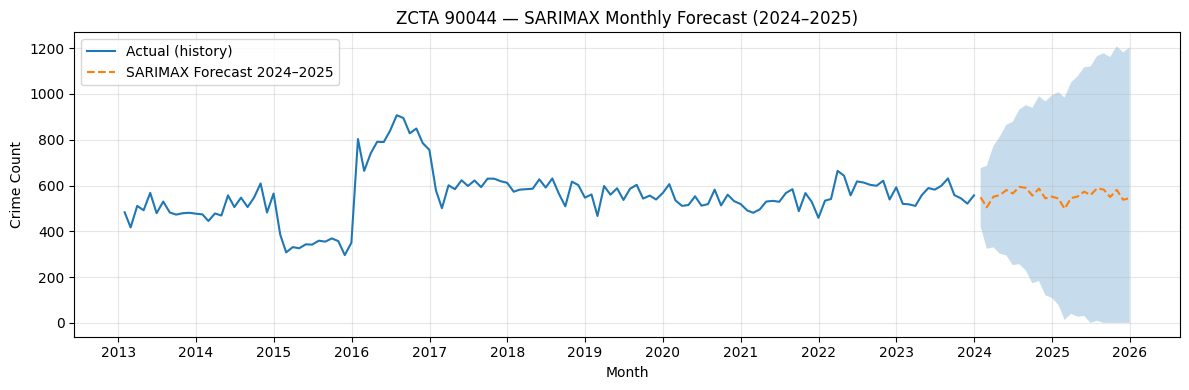

Top ZCTA by history: 90044
Total forecast (2024–2025) for 90044: 13384.3
Max monthly forecast: 2024-07-31 → 594.4 [256.5, 932.2]


In [26]:
# ============================================
#  ZCTA-LEVEL MONTHLY FORECAST — SARIMAX (with Population Regressors)
#  Train: up to 2023-12  →  Forecast: 2024-01..2025-12 (24 months)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.statespace.sarimax import SARIMAX

# --------------------------------------------
# 1) Prep monthly crime per ZCTA
# --------------------------------------------
crime = crime.copy()
crime["DATE OCC"] = pd.to_datetime(crime["DATE OCC"], errors="coerce")
crime = crime.dropna(subset=["DATE OCC", "ZCTA"])

def _to_zcta_str(x):
    try:
        return f"{int(float(x)):05d}"
    except:
        return np.nan

crime["ZCTA"] = crime["ZCTA"].apply(_to_zcta_str)
crime = crime[crime["ZCTA"].notna()]

zcta_monthly = (
    crime.groupby(["ZCTA", pd.Grouper(key="DATE OCC", freq="M")])
         .size()
         .reset_index(name="y")
         .rename(columns={"DATE OCC": "ds"})
)
zcta_monthly["YEAR"] = zcta_monthly["ds"].dt.year

# --------------------------------------------
# 2) Merge population features (as regressors)
# --------------------------------------------
EXOG = ["POP_TOTAL", "POV_RATE", "POP_DENSITY", "OLD_PCT"]

pop = pop.copy()
pop["ZCTA"] = pop["ZCTA"].apply(_to_zcta_str)
pop["YEAR"] = pd.to_numeric(pop["YEAR"], errors="coerce")
pop_small = pop[["ZCTA", "YEAR"] + EXOG]

zcta_monthly = zcta_monthly.merge(pop_small, on=["ZCTA","YEAR"], how="left")

# Fill regressors per ZCTA then global medians
for c in EXOG:
    zcta_monthly[c] = zcta_monthly.groupby("ZCTA")[c].transform(lambda x: x.ffill().bfill())
    zcta_monthly[c] = zcta_monthly[c].fillna(zcta_monthly[c].median())

# --------------------------------------------
# 3) Windows & future frame (2024–2025)
# --------------------------------------------
train_end   = pd.Timestamp("2023-12-31")
fc_start    = pd.Timestamp("2024-01-31")
fc_end      = pd.Timestamp("2025-12-31")
future_idx  = pd.date_range(fc_start, fc_end, freq="M")
future_year = pd.DataFrame({"ds": future_idx, "YEAR": future_idx.year})

# forward-fill last known exog per ZCTA into 2024–2025
latest_year_df = pop_small.sort_values(["ZCTA","YEAR"]).dropna(subset=["ZCTA","YEAR"])

def _future_exog_for_zcta(zcta):
    z = latest_year_df[latest_year_df["ZCTA"] == zcta]
    if z.empty:
        # fallback: use global medians from training data
        vals = {c: zcta_monthly[c].median() for c in EXOG}
    else:
        last = z.iloc[-1]
        vals = {c: last[c] for c in EXOG}
    fut = future_year.copy()
    for c in EXOG:
        fut[c] = vals[c]
    fut["ZCTA"] = zcta
    return fut

# --------------------------------------------
# 4) SARIMAX fit/forecast per ZCTA
#    (order & seasonal_order set for monthly data)
# --------------------------------------------
def fit_forecast_sarimax_zcta(df):
    z = df.sort_values("ds").copy()
    # history up to 2023-12
    hist = z[z["ds"] <= train_end].copy()
    if len(hist) < 24 or hist["y"].sum() < 20:
        return pd.DataFrame(), {"status": "too_short"}

    # set monthly index, fill missing months
    hist = hist.set_index("ds").asfreq("M")
    hist["y"] = hist["y"].fillna(0)

    # exog for training
    exog_train = hist[EXOG].copy()

    # build future exog (2024–2025)
    zcta = df["ZCTA"].iloc[0]
    fut_exog = _future_exog_for_zcta(zcta)
    fut_exog = fut_exog.set_index("ds")[EXOG].asfreq("M")

    # SARIMAX model
    try:
        model = SARIMAX(
            endog=hist["y"],
            exog=exog_train,
            order=(1,1,1),
            seasonal_order=(1,1,1,12),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        res = model.fit(disp=False)

        steps = len(fut_exog)
        fc_res = res.get_forecast(steps=steps, exog=fut_exog)
        sf = fc_res.summary_frame()  # has 'mean', 'mean_ci_lower', 'mean_ci_upper'

        out = pd.DataFrame({
            "ds": sf.index,
            "yhat": np.clip(sf["mean"].values, a_min=0, a_max=None),
            "yhat_lower": np.clip(sf["mean_ci_lower"].values, a_min=0, a_max=None),
            "yhat_upper": np.clip(sf["mean_ci_upper"].values, a_min=0, a_max=None),
            "ZCTA": zcta
        })
        return out, {"status": "ok"}

    except Exception as e:
        return pd.DataFrame(), {"status": f"error: {e}"}

# --------------------------------------------
# 5) Run all ZCTAs
# --------------------------------------------
all_fc, all_stats = [], []
for zcta, dfz in zcta_monthly.groupby("ZCTA"):
    fc, st = fit_forecast_sarimax_zcta(dfz.assign(ZCTA=zcta))
    st["ZCTA"] = zcta
    all_stats.append(st)
    if not fc.empty:
        all_fc.append(fc)

forecasts_24_25 = pd.concat(all_fc, ignore_index=True) if all_fc else pd.DataFrame()
stats_df = pd.DataFrame(all_stats)
print(f"Finished SARIMAX for {stats_df['ZCTA'].nunique()} ZCTAs")
print(stats_df["status"].value_counts(dropna=False).to_string())

if forecasts_24_25.empty:
    raise RuntimeError("No forecasts generated. Check inputs and dates.")

# --------------------------------------------
# 6) SAME top ZCTA as before (highest historical total)
# --------------------------------------------
top_zcta = (
    zcta_monthly.groupby("ZCTA")["y"].sum().sort_values(ascending=False).index[0]
)
fc_top = forecasts_24_25[forecasts_24_25["ZCTA"] == top_zcta].sort_values("ds")
hist_top = zcta_monthly[zcta_monthly["ZCTA"] == top_zcta].sort_values("ds")

# --------------------------------------------
# 7) Plot (history + SARIMAX forecast)
# --------------------------------------------
plt.figure(figsize=(12,4))
plt.plot(hist_top["ds"], hist_top["y"], label="Actual (history)", linewidth=1.5)
plt.plot(fc_top["ds"], fc_top["yhat"], linestyle="--", label="SARIMAX Forecast 2024–2025", linewidth=1.5)
plt.fill_between(fc_top["ds"], fc_top["yhat_lower"], fc_top["yhat_upper"], alpha=0.25)
plt.title(f"ZCTA {top_zcta} — SARIMAX Monthly Forecast (2024–2025)")
plt.xlabel("Month"); plt.ylabel("Crime Count")
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

# --------------------------------------------
# 8) Quick text summary (same style)
# --------------------------------------------
pair_total = fc_top["yhat"].sum()
mx_row = fc_top.loc[fc_top["yhat"].idxmax()]
print(f"Top ZCTA by history: {top_zcta}")
print(f"Total forecast (2024–2025) for {top_zcta}: {pair_total:.1f}")
print(f"Max monthly forecast: {mx_row['ds'].date()} → {mx_row['yhat']:.1f} "
      f"[{mx_row['yhat_lower']:.1f}, {mx_row['yhat_upper']:.1f}]")


Overall Accuracy Comparison (Top Performers)

Prophet strengths
Handles nonlinear trends and long-term seasonal cycles more flexibly.
Robust for smooth series and ZCTAs with fewer abrupt shifts.
More consistent (less variation across ZCTAs).

SARIMAX strengths
Better for well-behaved, regular time series with steady population changes.
Captures autoregressive patterns precisely when the series has consistent monthly rhythm.

Key Insight
Prophet tends to slightly over-smooth fluctuations, while SARIMAX captures short-term volatility better.

In [27]:
# # ============================================
# #  PROPHET PER (ZCTA × CRM CD Main Type)
# # Train: 2013–2022 → Forecast & evaluate: 2023
# # Regressors: POP_TOTAL, POV_RATE, POP_DENSITY, OLD_PCT
# # ============================================

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from sklearn.metrics import mean_absolute_error, mean_squared_error

# # Prophet (install if needed)
# try:
#     from prophet import Prophet
# except Exception:
#     !pip -q install prophet
#     from prophet import Prophet

# # tqdm (optional)
# try:
#     from tqdm import tqdm
# except Exception:
#     def tqdm(x, **k): return x

# # ---------------------------
# # 1) Build monthly series per ZCTA × Crime Type
# # ---------------------------
# crime_work = crime.copy()
# crime_work["DATE OCC"] = pd.to_datetime(crime_work["DATE OCC"], errors="coerce")

# # normalize ZCTA to 5-digit strings
# def _to_zcta_str(x):
#     try:
#         return f"{int(float(x)):05d}"
#     except:
#         return np.nan

# crime_work["ZCTA"] = crime_work["ZCTA"].apply(_to_zcta_str)
# crime_work = crime_work.dropna(subset=["DATE OCC", "ZCTA", "CRM CD Main Type"])

# # monthly counts per ZCTA × crime type
# monthly = (
#     crime_work.groupby(["ZCTA", "CRM CD Main Type", pd.Grouper(key="DATE OCC", freq="M")])
#               .size()
#               .reset_index(name="crime_count")
#               .rename(columns={"DATE OCC": "ds"})
# )
# monthly["YEAR"] = monthly["ds"].dt.year

# # ---------------------------
# # 2) Merge population features
# # ---------------------------
# pop_work = pop.copy()
# pop_work["ZCTA"] = pop_work["ZCTA"].apply(_to_zcta_str)
# pop_work["YEAR"] = pd.to_numeric(pop_work["YEAR"], errors="coerce")

# exog_cols = ["POP_TOTAL", "POV_RATE", "POP_DENSITY", "OLD_PCT"]
# pop_small = pop_work[["ZCTA", "YEAR"] + exog_cols].copy()

# monthly = monthly.merge(pop_small, on=["ZCTA","YEAR"], how="left")

# # global medians as fallback
# overall_medians = {c: pop_small[c].median() for c in exog_cols}

# # ---------------------------
# # 3) Modeling function (Prophet)
# # ---------------------------
# def fit_one_pair(df_pair: pd.DataFrame):
#     """
#     One (ZCTA × CRM CD Main Type) group.
#     Train on <= 2022, forecast 2023, evaluate MAE/RMSE.
#     """
#     df = df_pair.copy().sort_values("ds")
#     # complete monthly index; fill missing months with 0 crimes
#     df = df.set_index("ds").asfreq("M")
#     df["crime_count"] = df["crime_count"].fillna(0)
#     df["YEAR"] = df.index.year

#     # fill exogenous regressors (ffill/bfill; then global median if still NaN)
#     for c in exog_cols:
#         if c not in df.columns:
#             df[c] = np.nan
#         df[c] = df[c].astype(float).replace([np.inf, -np.inf], np.nan)
#         df[c] = df[c].fillna(method="ffill").fillna(method="bfill")
#         if df[c].isna().any():
#             df[c] = df[c].fillna(overall_medians[c])

#     # split
#     train = df[df.index.year <= 2022].reset_index()
#     test  = df[df.index.year == 2023].reset_index()

#     # require enough history & test data
#     if len(train) < 24 or len(test) == 0:
#         return pd.DataFrame(), {"MAE": np.nan, "RMSE": np.nan, "status": "too_short"}

#     # prophet model
#     m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False, seasonality_mode="additive")
#     for c in exog_cols:
#         m.add_regressor(c)

#     train_fit = train[["ds", "crime_count"] + exog_cols].rename(columns={"crime_count": "y"})
#     m.fit(train_fit)

#     future = test[["ds"] + exog_cols]
#     fc = m.predict(future)

#     pred = fc[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
#         test[["ds", "crime_count"]], on="ds", how="left"
#     )

#     mae  = mean_absolute_error(pred["crime_count"], pred["yhat"])
#     rmse = np.sqrt(mean_squared_error(pred["crime_count"], pred["yhat"]))
#     return pred, {"MAE": float(mae), "RMSE": float(rmse), "status": "ok"}

# # ---------------------------
# # 4) Run for every ZCTA × Crime Type
# #    (optionally, limit to top N frequent crime types to save time)
# # ---------------------------
# all_fc, all_metrics = [], []

# # OPTIONAL: uncomment to filter to top K crime types citywide
# # top_types = (crime_work["CRM CD Main Type"].value_counts().head(12).index.tolist())
# # monthly = monthly[monthly["CRM CD Main Type"].isin(top_types)]

# group_cols = ["ZCTA", "CRM CD Main Type"]
# for (zcta, ctype), g in tqdm(monthly.groupby(group_cols), desc="Prophet per (ZCTA × Crime Type)"):
#     fc, met = fit_one_pair(g)
#     met.update({"ZCTA": zcta, "CrimeType": ctype})
#     all_metrics.append(met)
#     if not fc.empty:
#         fc["ZCTA"] = zcta
#         fc["CrimeType"] = ctype
#         all_fc.append(fc)

# forecasts = pd.concat(all_fc, ignore_index=True) if all_fc else pd.DataFrame()
# metrics   = pd.DataFrame(all_metrics)

# print(f" Models built: {metrics.shape[0]} (pairs). With forecasts: {forecasts[['ZCTA','CrimeType']].drop_duplicates().shape[0]}")

# # ---------------------------
# # 5) Summaries
# # ---------------------------
# print("\n Best 15 (lowest RMSE) pairs:")
# display(
#     metrics.sort_values("RMSE").head(15)[["ZCTA","CrimeType","MAE","RMSE","status"]]
#           .style.format({"MAE":"{:.2f}","RMSE":"{:.2f}"})
# )

# print("\n Average RMSE across modeled pairs:", round(metrics["RMSE"].mean(), 3))

# # ---------------------------
# # 6) Plot example: pick the (ZCTA, CrimeType) with highest total crimes
# # ---------------------------
# if not forecasts.empty:
#     # compute historical totals from the original monthly table
#     totals = (
#         monthly.groupby(["ZCTA","CRM CD Main Type"])["crime_count"]
#         .sum()
#         .sort_values(ascending=False)
#     )
#     zcta_top, ctype_top = totals.index[0]
#     print(f"\n Highest-total pair: ZCTA {zcta_top} — {ctype_top}")

#     # actual 2023 for that pair
#     actual23 = (
#         monthly[(monthly["ZCTA"] == zcta_top) & (monthly["CRM CD Main Type"] == ctype_top) & (monthly["ds"].dt.year == 2023)]
#         .sort_values("ds")[["ds","crime_count"]]
#     )
#     # forecast rows for that pair
#     fc_top = forecasts[(forecasts["ZCTA"] == zcta_top) & (forecasts["CrimeType"] == ctype_top)].sort_values("ds")

#     import matplotlib.dates as mdates
#     plt.figure(figsize=(12,6))
#     plt.plot(actual23["ds"], actual23["crime_count"], "ko-", label="Actual 2023")
#     plt.plot(fc_top["ds"], fc_top["yhat"], "b--", label="Prophet Forecast (2023)")
#     plt.fill_between(fc_top["ds"], fc_top["yhat_lower"], fc_top["yhat_upper"], color="skyblue", alpha=0.3)
#     plt.title(f" Prophet Forecast — ZCTA {zcta_top} × {ctype_top} (Population-only)")
#     plt.xlabel("Month"); plt.ylabel("Crime Count")
#     plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
#     plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
#     plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()
# else:
#     print("No forecasts to plot.")


In [28]:
# # ============================================
# # SARIMAX per (ZCTA × CRM CD Main Type)
# # Train: 2013–2022 → Forecast: 2023
# # Regressors: POP_TOTAL, POV_RATE, POP_DENSITY, OLD_PCT
# # ============================================

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib.dates as mdates
# from tqdm import tqdm
# from sklearn.metrics import mean_absolute_error, mean_squared_error
# from statsmodels.tsa.statespace.sarimax import SARIMAX

# # -----------------------------
# #  Prepare monthly data per ZCTA × CRM CD Main Type
# # -----------------------------
# crime_work = crime.copy()
# crime_work["DATE OCC"] = pd.to_datetime(crime_work["DATE OCC"], errors="coerce")

# # normalize ZCTA codes
# def _to_zcta_str(x):
#     try:
#         return f"{int(float(x)):05d}"
#     except:
#         return np.nan

# crime_work["ZCTA"] = crime_work["ZCTA"].apply(_to_zcta_str)
# crime_work = crime_work.dropna(subset=["DATE OCC", "ZCTA", "CRM CD Main Type"])

# # monthly aggregation
# monthly = (
#     crime_work.groupby(["ZCTA", "CRM CD Main Type", pd.Grouper(key="DATE OCC", freq="M")])
#               .size()
#               .reset_index(name="crime_count")
#               .rename(columns={"DATE OCC": "ds"})
# )
# monthly["YEAR"] = monthly["ds"].dt.year

# # -----------------------------
# #  Merge population features
# # -----------------------------
# pop_work = pop.copy()
# pop_work["ZCTA"] = pop_work["ZCTA"].apply(_to_zcta_str)
# pop_work["YEAR"] = pd.to_numeric(pop_work["YEAR"], errors="coerce")

# exog_cols = ["POP_TOTAL", "POV_RATE", "POP_DENSITY", "OLD_PCT"]
# pop_small = pop_work[["ZCTA", "YEAR"] + exog_cols]
# monthly = monthly.merge(pop_small, on=["ZCTA","YEAR"], how="left")

# # fill missing values (forward/backward then median)
# for col in exog_cols:
#     monthly[col] = monthly.groupby("ZCTA")[col].transform(lambda x: x.ffill().bfill())
#     monthly[col] = monthly[col].fillna(monthly[col].median())

# # -----------------------------
# #  Define SARIMAX model per pair
# # -----------------------------
# def fit_sarimax_pair(df_pair):
#     """Fit SARIMAX for one (ZCTA × CRM CD Main Type)"""
#     df = df_pair.sort_values("ds").set_index("ds").asfreq("M")
#     df["crime_count"] = df["crime_count"].fillna(0)

#     for col in exog_cols:
#         if col not in df.columns:
#             df[col] = np.nan
#         df[col] = df[col].fillna(method="ffill").fillna(method="bfill").fillna(df[col].median())

#     # Split data
#     train = df[df.index.year <= 2022]
#     test  = df[df.index.year == 2023]
#     if len(train) < 24 or len(test) == 0:
#         return pd.DataFrame(), {"MAE": np.nan, "RMSE": np.nan, "status": "too_short"}

#     try:
#         model = SARIMAX(
#             train["crime_count"],
#             exog=train[exog_cols],
#             order=(1,1,1),
#             seasonal_order=(1,1,1,12),
#             enforce_stationarity=False,
#             enforce_invertibility=False
#         )
#         res = model.fit(disp=False)
#         fc = res.get_forecast(steps=len(test), exog=test[exog_cols])
#         sf = fc.summary_frame()

#         pred = pd.DataFrame({
#             "ds": test.index,
#             "actual": test["crime_count"].values,
#             "yhat": sf["mean"].values,
#             "yhat_lower": sf["mean_ci_lower"].values,
#             "yhat_upper": sf["mean_ci_upper"].values
#         })

#         mae = mean_absolute_error(pred["actual"], pred["yhat"])
#         rmse = np.sqrt(mean_squared_error(pred["actual"], pred["yhat"]))

#         return pred, {"MAE": mae, "RMSE": rmse, "status": "ok"}

#     except Exception as e:
#         return pd.DataFrame(), {"MAE": np.nan, "RMSE": np.nan, "status": f"error:{str(e)}"}

# # -----------------------------
# #  Loop through all (ZCTA × CRM CD Main Type)
# # -----------------------------
# all_fc, all_metrics = [], []
# for (zcta, ctype), dfz in tqdm(monthly.groupby(["ZCTA","CRM CD Main Type"]), desc="SARIMAX models"):
#     fc, m = fit_sarimax_pair(dfz)
#     m["ZCTA"] = zcta
#     m["CrimeType"] = ctype
#     all_metrics.append(m)
#     if not fc.empty:
#         fc["ZCTA"] = zcta
#         fc["CrimeType"] = ctype
#         all_fc.append(fc)

# forecasts = pd.concat(all_fc, ignore_index=True) if all_fc else pd.DataFrame()
# metrics   = pd.DataFrame(all_metrics)

# print(f"\n Completed SARIMAX models: {len(metrics)} pairs")
# display(metrics.head())

# # -----------------------------
# #  Summary results
# # -----------------------------
# print("\n Top 15 Best Performing (lowest RMSE):")
# display(metrics.sort_values("RMSE").head(15)[["ZCTA","CrimeType","MAE","RMSE","status"]]
#         .style.format({"MAE":"{:.2f}","RMSE":"{:.2f}"}))

# print(f"\n Average RMSE across models: {metrics['RMSE'].mean():.3f}")

# # -----------------------------
# #  Plot example (highest-total crime pair)
# # -----------------------------
# if not forecasts.empty:
#     totals = (
#         monthly.groupby(["ZCTA","CRM CD Main Type"])["crime_count"]
#         .sum()
#         .sort_values(ascending=False)
#     )
#     zcta_top, ctype_top = totals.index[0]
#     print(f"\n Plotting top crime pair: ZCTA {zcta_top} — {ctype_top}")

#     fc_top = forecasts[(forecasts["ZCTA"] == zcta_top) & (forecasts["CrimeType"] == ctype_top)]
#     actual = monthly[(monthly["ZCTA"] == zcta_top) & (monthly["CRM CD Main Type"] == ctype_top)]

#     plt.figure(figsize=(12,6))
#     plt.plot(actual["ds"], actual["crime_count"], "k-", label="Actual")
#     plt.plot(fc_top["ds"], fc_top["yhat"], "r--", label="SARIMAX Forecast")
#     plt.fill_between(fc_top["ds"], fc_top["yhat_lower"], fc_top["yhat_upper"], color="salmon", alpha=0.3)
#     plt.title(f" SARIMAX Forecast — {ctype_top} (ZCTA {zcta_top})")
#     plt.xlabel("Month"); plt.ylabel("Crime Count")
#     plt.gca().xaxis.set_major_locator(mdates.YearLocator())
#     plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
#     plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
#     plt.show()
# else:
#     print("No forecast results to plot.")


In [29]:
# # ============================================
# # SARIMAX per (ZCTA × CRM CD Main Type)
# # Train: all history up to 2023-12 → Forecast: 2024–2025 (24 months)
# # Regressors: POP_TOTAL, POV_RATE, POP_DENSITY, OLD_PCT
# # ============================================

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib.dates as mdates
# from tqdm import tqdm
# from statsmodels.tsa.statespace.sarimax import SARIMAX

# # -----------------------------
# # 1) Config
# # -----------------------------
# EXOG_COLS = ["POP_TOTAL", "POV_RATE", "POP_DENSITY", "OLD_PCT"]
# FORECAST_START = "2024-01-31"
# FORECAST_END   = "2025-12-31"
# MIN_TRAIN_LEN  = 36      # need enough data for seasonal=12
# MIN_TOTAL_CNT  = 20      # skip ultra-sparse series
# MAX_ALLOWED_YHAT = 1e5   # explosion guard

# # -----------------------------
# # 2) Utilities
# # -----------------------------
# def _to_zcta_str(x):
#     try:
#         return f"{int(float(x)):05d}"
#     except Exception:
#         return np.nan

# def _prep_exog_numeric(df, cols):
#     for c in cols:
#         if c not in df.columns:
#             df[c] = np.nan
#         df[c] = pd.to_numeric(df[c], errors="coerce")
#     return df

# def _scale_exog(train_exog, ref_exog):
#     means = train_exog.mean()
#     stds  = train_exog.std().replace(0, np.nan)
#     scaled_train = (train_exog - means) / stds
#     scaled_ref   = (ref_exog  - means) / stds
#     keep = [c for c in train_exog.columns if scaled_train[c].notna().any()]
#     return scaled_train[keep], scaled_ref[keep], keep

# def build_future_exog_for_zcta(zcta, template_months, latest_year_df):
#     """Build future (2024–2025) exogenous features for one ZCTA by ffill last known year."""
#     zdf = latest_year_df[latest_year_df["ZCTA"] == zcta].sort_values("YEAR")
#     if zdf.empty:
#         vals = {c: monthly[c].median() for c in EXOG_COLS}
#     else:
#         row = zdf.iloc[-1]
#         vals = {c: row[c] for c in EXOG_COLS}
#     fut = pd.DataFrame({"ds": template_months, "YEAR": template_months.year})
#     for c in EXOG_COLS:
#         fut[c] = vals[c]
#     fut["ZCTA"] = zcta
#     return fut

# # -----------------------------
# # 3) Prepare monthly data per (ZCTA × CRM CD Main Type)
# # -----------------------------
# crime_work = crime.copy()
# crime_work["DATE OCC"] = pd.to_datetime(crime_work["DATE OCC"], errors="coerce")
# crime_work["ZCTA"] = crime_work["ZCTA"].apply(_to_zcta_str)
# crime_work = crime_work.dropna(subset=["DATE OCC", "ZCTA", "CRM CD Main Type"])

# monthly = (
#     crime_work
#       .groupby(["ZCTA", "CRM CD Main Type", pd.Grouper(key="DATE OCC", freq="M")])
#       .size()
#       .reset_index(name="crime_count")
#       .rename(columns={"DATE OCC": "ds"})
# )
# monthly["YEAR"] = monthly["ds"].dt.year

# # -----------------------------
# # 4) Merge population features (exog) and fill
# # -----------------------------
# pop_work = pop.copy()
# pop_work["ZCTA"] = pop_work["ZCTA"].apply(_to_zcta_str)
# pop_work["YEAR"] = pd.to_numeric(pop_work["YEAR"], errors="coerce")

# pop_small = pop_work[["ZCTA", "YEAR"] + EXOG_COLS]
# monthly = monthly.merge(pop_small, on=["ZCTA","YEAR"], how="left")

# # fill exog by ZCTA (ffill/bfill), then global median for any leftovers
# for col in EXOG_COLS:
#     monthly[col] = monthly.groupby("ZCTA")[col].transform(lambda x: x.ffill().bfill())
#     monthly[col] = monthly[col].fillna(monthly[col].median())

# # check numeric types
# monthly = _prep_exog_numeric(monthly, EXOG_COLS)

# # -----------------------------
# # 5) Future calendar + latest-year exog per ZCTA
# # -----------------------------
# future_idx = pd.date_range(FORECAST_START, FORECAST_END, freq="M")
# future_years = pd.DataFrame({"ds": future_idx, "YEAR": future_idx.year})
# latest_year_df = pop_small.sort_values(["ZCTA","YEAR"])  # includes any future-year rows if present

# # -----------------------------
# # 6) Fit + Forecast function (stable)
# # -----------------------------
# def fit_and_forecast_pair(df_pair):
#     """Fit SARIMAX on all history up to 2023-12, then forecast 2024–2025."""
#     df = df_pair.sort_values("ds").set_index("ds").asfreq("M")
#     df["crime_count"] = df["crime_count"].fillna(0)

#     # skip ultra-sparse series
#     if df["crime_count"].sum() < MIN_TOTAL_CNT or df.index.max() < pd.Timestamp("2020-12-31"):
#         return pd.DataFrame(), {"status":"too_sparse"}

#     # ensure exog present/filled historically
#     for c in EXOG_COLS:
#         if c not in df.columns:
#             df[c] = np.nan
#         df[c] = pd.to_numeric(df[c], errors="coerce").ffill().bfill().fillna(monthly[c].median())

#     # log1p transform target for stability
#     df["y"] = np.log1p(df["crime_count"])

#     # Train set: up to 2023-12 (adjust if your history goes later)
#     train = df[df.index <= "2023-12-31"]
#     if len(train) < MIN_TRAIN_LEN:
#         return pd.DataFrame(), {"status":"too_short"}

#     # Build future exog for this ZCTA, scale using TRAIN stats only
#     zcta = df_pair["ZCTA"].iloc[0]
#     fut_exog = build_future_exog_for_zcta(zcta, future_idx, latest_year_df).set_index("ds").asfreq("M")
#     fut_exog = _prep_exog_numeric(fut_exog, EXOG_COLS)

#     X_train, X_all, keep_cols = _scale_exog(train[EXOG_COLS], df[EXOG_COLS])
#     X_future = ((fut_exog[EXOG_COLS] - train[EXOG_COLS].mean()) /
#                 train[EXOG_COLS].std().replace(0, np.nan))[keep_cols]

#     # SARIMA with safer orders; enforce stability
#     model = SARIMAX(
#         train["y"],
#         exog=X_train,
#         order=(0,1,1),
#         seasonal_order=(0,1,1,12),
#         enforce_stationarity=True,
#         enforce_invertibility=True,
#         trend="n"
#     )
#     res = model.fit(disp=False)

#     # Forecast 24 steps
#     sf = res.get_forecast(steps=len(future_idx), exog=X_future).summary_frame()

#     # Back-transform + guards
#     yhat = np.expm1(sf["mean"].values)
#     ylo  = np.expm1(sf["mean_ci_lower"].values)
#     yhi  = np.expm1(sf["mean_ci_upper"].values)

#     out = pd.DataFrame({
#         "ds": future_idx,
#         "yhat": np.clip(yhat, 0, None),
#         "yhat_lower": np.clip(ylo, 0, None),
#         "yhat_upper": np.clip(yhi, 0, None),
#         "ZCTA": zcta,
#         "CrimeType": df_pair["CRM CD Main Type"].iloc[0],
#     })

#     # explosion guard
#     if not (np.isfinite(out["yhat"]).all() and out["yhat"].max() < MAX_ALLOWED_YHAT):
#         return pd.DataFrame(), {"status":"exploded"}

#     return out, {"status":"ok"}

# # -----------------------------
# # 7) Run for all (ZCTA × CrimeType)
# # -----------------------------
# all_fc, all_stats = [], []
# grouped = monthly.groupby(["ZCTA","CRM CD Main Type"], sort=False)

# for (zcta, ctype), dfz in tqdm(grouped, desc="SARIMAX 2024–2025"):
#     fc, stat = fit_and_forecast_pair(dfz)
#     stat["ZCTA"] = zcta
#     stat["CrimeType"] = ctype
#     all_stats.append(stat)
#     if not fc.empty:
#         all_fc.append(fc)

# forecasts_24_25 = pd.concat(all_fc, ignore_index=True) if all_fc else pd.DataFrame()
# stats_df = pd.DataFrame(all_stats)

# print(f"\nCompleted pairs: {len(stats_df)}")
# print(stats_df["status"].value_counts(dropna=False).to_string())

# if forecasts_24_25.empty:
#     raise RuntimeError("No forecasts generated. Check inputs and dates.")

# # -----------------------------
# # 8) Summaries you asked for
# # -----------------------------
# # 1) Pair with largest TOTAL forecast over 2024–2025
# pair_totals = (
#     forecasts_24_25.groupby(["ZCTA","CrimeType"])["yhat"]
#     .sum()
#     .sort_values(ascending=False)
# )
# top_zcta, top_ctype = pair_totals.index[0]
# top_total = pair_totals.iloc[0]
# print(f"\nTop forecasted pair by TOTAL (2024–2025): ZCTA {top_zcta} — {top_ctype} (sum={top_total:.1f})")

# # 2) Biggest MONTHLY forecast across all pairs/months
# idx_max = forecasts_24_25["yhat"].idxmax()
# row_max = forecasts_24_25.loc[idx_max]
# print(
#     f"Max monthly forecast (2024–2025): ZCTA {row_max['ZCTA']} — {row_max['CrimeType']} "
#     f"on {row_max['ds'].date()} (yhat={row_max['yhat']:.1f}, "
#     f"[{row_max['yhat_lower']:.1f}, {row_max['yhat_upper']:.1f}])"
# )

# # 3) Crime type with largest TOTAL forecast (sum over all ZCTAs)
# type_totals = (
#     forecasts_24_25.groupby("CrimeType")["yhat"]
#     .sum()
#     .sort_values(ascending=False)
# )
# top_type, top_type_total = type_totals.index[0], type_totals.iloc[0]
# print(f"Top crime type by TOTAL forecast (2024–2025): {top_type} (sum={top_type_total:.1f})")

# # 4) Citywide monthly sum and its max month
# city_month = forecasts_24_25.groupby("ds")["yhat"].sum()
# city_max_month = city_month.idxmax()
# print(f"Citywide max month (forecast): {city_max_month.date()} with {city_month.max():.1f} predicted crimes")

# # -----------------------------
# # 9) Plot the top TOTAL-forecast pair with historical context
# # -----------------------------
# hist_top = monthly[(monthly["ZCTA"] == top_zcta) & (monthly["CRM CD Main Type"] == top_ctype)].sort_values("ds")
# fc_top   = forecasts_24_25[(forecasts_24_25["ZCTA"] == top_zcta) & (forecasts_24_25["CrimeType"] == top_ctype)]

# plt.figure(figsize=(12,6))
# plt.plot(hist_top["ds"], hist_top["crime_count"], label="Actual (history)", linewidth=1.5)
# plt.plot(fc_top["ds"], fc_top["yhat"], linestyle="--", label="SARIMAX Forecast (2024–2025)", linewidth=1.5)
# plt.fill_between(fc_top["ds"], fc_top["yhat_lower"], fc_top["yhat_upper"], alpha=0.25)
# plt.title(f"Top Pair by Total Forecast (2024–2025): {top_ctype} — ZCTA {top_zcta}")
# plt.xlabel("Month"); plt.ylabel("Crime Count")
# ax = plt.gca()
# ax.xaxis.set_major_locator(mdates.YearLocator())
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
# plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
# plt.show()

# # -----------------------------
# # 10) (Optional) Save summaries
# # -----------------------------
# # with pd.ExcelWriter("sarimax_forecasts_2024_2025.xlsx") as xw:
# #     forecasts_24_25.to_excel(xw, "forecasts", index=False)
# #     pair_totals.reset_index(name="sum_yhat").to_excel(xw, "pair_totals", index=False)
# #     type_totals.reset_index(name="sum_yhat").to_excel(xw, "type_totals", index=False)
# # print("Saved: sarimax_forecasts_2024_2025.xlsx")
